# Heat Pump Installed Capacity Detection

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
import time
import json

import shap
import h5py

import xgboost as xgb

from matplotlib.patches import Polygon
from matplotlib import colors

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from hyperopt.early_stop import no_progress_loss

from typing import Tuple
from itertools import product
from math import ceil, floor
from scipy.stats import skew, kurtosis
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

from datetime import datetime, timedelta
from random import choice, sample, randrange, randint, uniform
from itertools import compress
from copy import deepcopy

from sklearn.metrics import (root_mean_squared_error, mean_absolute_percentage_error,
                             mean_absolute_error, r2_score, mean_squared_error)
from sklearn.model_selection import (cross_val_score, GridSearchCV, train_test_split,
                                     KFold, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression

from tqdm import tqdm, trange
import hplib as hpl


In [2]:
# ── Data generation ───────────────────────────────────────────────────────
regenerate_substations    = False   # build synthetic substations from HEAPO
regenerate_time_features  = False   # extract 96-slot time-of-day features

# ── Substation hockey-stick fits (no model file, always fast) ─────────────
refit_hockey_daily        = False   # daily min-T / max-Load fit per substation
refit_hockey_hourly       = False   # 4-window hourly fit per substation

# ── XGBoost models ────────────────────────────────────────────────────────
retrain_xgb_time          = False   # XGBoost on time-of-day features
retrain_xgb_time_hockey   = False   # XGBoost on time-of-day + hockey-stick coefficients
retrain_xgb_windowed_hdd  = False   # XGBoost on windowed HDD-binned features

# ── Ridge / PLS models ────────────────────────────────────────────────────
retrain_ridge_time        = False   # Ridge on time-of-day features
retrain_ridge_time_hockey = False   # Ridge on time-of-day + hockey-stick coefficients
retrain_ridge_windowed_hdd= False   # Ridge with feature-selection on windowed HDD features
retrain_pls_time_series   = False   # PLS on raw load time series
retrain_pls_features      = False   # PLS on time-of-day feature matrix


In [3]:
# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, folder_path)
sys.path.insert(0, folder_path + '/Desktop/NILM/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = 'data/heapo_data'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

Check households with submetered Heat Pumps

In [4]:
df_protocols = heapo.get_all_protocols()
households = heapo.get_all_households()

submeter_datarange = {}

start_date = '2023-01-01 00:00:00+00:00'
end_date = '2023-12-31 23:45:00+00:00'

full_year_no_weekends = pd.date_range(start=start_date, end=end_date, freq='15min')
# full_year_no_weekends = full_year_no_weekends[full_year_no_weekends.weekday < 5]  # only consider weekdays

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
        df_house.dropna(subset=['kWh_received_HeatPump', 'kWh_received_Total', 'kWh_received_Other'],inplace=True)
        # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
        if len(df_house) > full_year_no_weekends.shape[0] * 0.8:  # only consider households with at least 80% of the data available
            submeter_datarange[household_id] = (df_house['Timestamp'].min(), df_house['Timestamp'].max(), len(df_house) * timedelta(minutes=15), full_year_no_weekends.shape[0] * timedelta(minutes=15) - len(df_house) * timedelta(minutes=15))
    except:
        pass


Get corresponding weather stations' IDs

In [5]:
df_meta = heapo.get_meta_data_overview()

datarangeDf = pd.DataFrame.from_dict(submeter_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)
datarangeDf = datarangeDf.join(df_meta.set_index('Household_ID')['Weather_ID'])

In [6]:
hp_peaks = []
for household_id in datarangeDf.index:
    df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
    df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
    # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
    hp_load = df_house['kWh_received_HeatPump'].values * 4
    hp_load = hp_load[~np.isnan(hp_load)]
    hp_peak = hp_load.max()
    hp_99_9 = np.quantile(hp_load, 0.999)
    hp_time = df_house.iloc[np.argmax(hp_load)]['Timestamp']
    hp_peaks.append((hp_peak, hp_99_9, hp_time))

In [7]:
hp_peaks_df = pd.DataFrame({'Household_ID': datarangeDf.index, 'HP_Peak': [hp[0] for hp in hp_peaks], 'HP_99_9': [hp[1] for hp in hp_peaks], 'Timestamp': [hp[2] for hp in hp_peaks]})
hp_peaks_df.sort_values('HP_Peak', ascending=False, inplace=True)
hp_peaks_df

,Household_ID,HP_Peak,HP_99_9,Timestamp
44,1186910,28.388,20.030828,2023-02-28 00:30:00+00:00
32,611797,19.360,10.080684,2023-01-24 17:45:00+00:00
35,6687105,13.984,13.752000,2023-11-27 00:15:00+00:00
11,1181060,13.700,13.520000,2023-12-14 01:15:00+00:00
30,120706,12.820,9.787752,2023-04-13 06:15:00+00:00
22,818882,12.152,11.052228,2023-11-24 16:15:00+00:00
3,816910,11.704,9.220912,2023-02-10 08:00:00+00:00
6,884673,10.720,8.572456,2023-10-18 12:45:00+00:00
25,109105,10.672,10.392000,2023-01-21 03:15:00+00:00
47,667399,10.092,9.116000,2023-11-29 00:30:00+00:00


Check weather data availability

In [8]:
weather_ids = datarangeDf['Weather_ID'].unique()

weather_datarange = {}

full_year = pd.date_range(start=start_date, end=end_date, freq='h')
# full_year_no_weekends = full_year[full_year.weekday < 5]  # only consider weekdays

for weather_id in weather_ids:
    try:
        df_weather = heapo.load_weather_data(weather_id, resolution='hourly')
        df_weather = df_weather[(df_weather['Timestamp'] >= pd.to_datetime(start_date)) & (df_weather['Timestamp'] <= pd.to_datetime(end_date))]
        # df_weather = df_weather[df_weather['Timestamp'].dt.weekday < 5]        # only consider weekdays
        df_weather.dropna(subset=['Temperature_avg_hourly'],inplace=True)
        if len(df_weather) > full_year.shape[0] * 0.8: # at least 80% of data for one year
            weather_datarange[weather_id] = (df_weather['Timestamp'].min(), df_weather['Timestamp'].max(), len(df_weather) * timedelta(minutes=60), full_year.shape[0] * timedelta(minutes=60) - len(df_weather) * timedelta(minutes=60))
    except:
        pass

In [9]:
weather_datarangeDf = pd.DataFrame.from_dict(weather_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)

datarangeDf = datarangeDf[datarangeDf['Weather_ID'].isin(weather_datarangeDf.index)]

### Fit household HP and smart-meter load vs temperature (hockey-stick model)

In [109]:
# ---------------------------------------------------------------------------
# Hockey-stick model: Load(T) = base_load + hp_sensitivity * max(0, T_balance - T)
#
# Replaces the unconstrained 2-segment pwlf fit used throughout this
# section. Unconstrained pwlf has 5 free parameters and can land on
# degenerate solutions (positive cold-weather slopes, breakpoints outside
# the heating range) -- the original code patched this after the fact
# (`if slopes[0] > 0: slopes[0] = 0`). This model has only 3 parameters,
# all physically bounded, so degenerate fits can't happen in the first
# place, and `hp_sensitivity` maps directly onto installed HP capacity.
# ---------------------------------------------------------------------------
from scipy.optimize import curve_fit


def hockey_stick(T, base_load, hp_sensitivity, T_balance):
    return base_load + hp_sensitivity * np.maximum(0, T_balance - T)


def fit_hockey_stick(x, y, T_balance_bounds=(8, 20)):
    """Fit a 3-parameter hockey-stick load-vs-temperature curve.

    Returns (base_load, hp_sensitivity, T_balance, r2). Raises if curve_fit
    fails (e.g. too few / degenerate points) so callers can catch and skip.
    """
    p0 = [np.median(y), 0.5, np.mean(T_balance_bounds)]
    bounds = (
        [0, 0, T_balance_bounds[0]],
        [np.inf, np.inf, T_balance_bounds[1]]
    )
    popt, _ = curve_fit(hockey_stick, x, y, p0=p0, bounds=bounds, maxfev=5000)
    y_pred = hockey_stick(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    base_load, hp_sensitivity, T_balance = popt
    return base_load, hp_sensitivity, T_balance, r2


def daily_min_max_heating_season(temperature, load, heating_season_thresh=16.0, resolution='D'):
    """Build (daily_min_temperature, daily_max_load) pairs, restricted to
    heating-season days.

    Using the daily MINIMUM temperature (rather than the daily mean) ties
    the fit to the coldest part of the day, when HPs run hardest. Using the
    daily MAXIMUM load (rather than the mean) ties it to peak demand, which
    is what HP_Peak actually measures. Warm-season days are dropped so they
    don't bias the slope / balance-temperature estimate towards a flat,
    near-zero-sensitivity cloud of points.
    """
    daily_temp_min = temperature.resample(resolution).min()
    daily_load_max = load.resample(resolution).max()
    sm_data = pd.DataFrame({
        'Temperature_min': daily_temp_min,
        'Total_Load_max': daily_load_max
    }).dropna()
    sm_data = sm_data[sm_data['Temperature_min'] < heating_season_thresh]
    return sm_data['Temperature_min'].values, sm_data['Total_Load_max'].values

def daily_mean_mean_heating_season(temperature, load, heating_season_thresh=16.0, resolution='D'):
    """Build (daily_mean_temperature, daily_mean_load) pairs, restricted to
    heating-season days.

    Using the daily MEAN temperature (rather than the daily min) ties
    the fit to the coldest part of the day, when HPs run hardest. Using the
    daily MEAN load (rather than the max) ties it to peak demand, which
    is what HP_Peak actually measures. Warm-season days are dropped so they
    don't bias the slope / balance-temperature estimate towards a flat,
    near-zero-sensitivity cloud of points.
    """
    daily_temp_mean = temperature.resample(resolution).mean()
    daily_load_mean = load.resample(resolution).mean()
    sm_data = pd.DataFrame({
        'Temperature_mean': daily_temp_mean,
        'Total_Load_mean': daily_load_mean
    }).dropna()
    sm_data = sm_data[sm_data['Temperature_mean'] < heating_season_thresh]
    return sm_data['Temperature_mean'].values, sm_data['Total_Load_mean'].values

In [11]:
T_BALANCE_BOUNDS = (8, 20)     # degC, plausible balance-temperature range
HEATING_SEASON_THRESH = 12.0   # degC, daily-min threshold to keep a day
MIN_HEATING_DAYS = 20          # minimum heating-season days required to attempt a fit

def fit_household_hockey_stick(
    household_id,
    load_col,
    heapo_obj,
    datarange_df,
    start_date,
    end_date,
    t_balance_bounds=T_BALANCE_BOUNDS,
    heating_season_thresh=HEATING_SEASON_THRESH,
    min_heating_days=MIN_HEATING_DAYS,
):
    """Load one household's data and fit the hockey-stick model.

    Returns (household_id, base_load, hp_sensitivity, T_balance, r2)
    or None if the fit cannot be computed.
    """
    try:
        sm_data = heapo_obj.load_smart_meter_data(household_id, resolution='15min')
        weather_data = heapo_obj.load_weather_data(
            datarange_df.loc[household_id, 'Weather_ID'], resolution='hourly')

        sm_data = sm_data.dropna(subset=[load_col])
        sm_data = sm_data[(sm_data['Timestamp'] >= pd.to_datetime(start_date)) &
                          (sm_data['Timestamp'] <= pd.to_datetime(end_date))]
        sm_data = (sm_data[['Timestamp', load_col]]
                   .set_index('Timestamp')
                   .resample('15min').sum())

        weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
        weather_data = weather_data[
            (weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
            (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]
        weather_data = (weather_data[['Timestamp', 'Temperature_avg_hourly']]
                        .set_index('Timestamp')
                        .resample('15min').mean()
                        .interpolate(method='time'))

        load_series = sm_data[load_col] * 4          # kWh/15min → kW
        temp_series  = weather_data['Temperature_avg_hourly']

        # x, y = daily_min_max_heating_season(temp_series, load_series, heating_season_thresh)
        x, y = daily_mean_mean_heating_season(temp_series, load_series, heating_season_thresh)
        if len(x) < min_heating_days:
            return None

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, t_balance_bounds)
        return (household_id, base_load, hp_sensitivity, T_balance, r2)
    except Exception:
        return None


# ── Fit submetered HP load ────────────────────────────────────────────────
hp_fit_results = [
    fit_household_hockey_stick(hid, 'kWh_received_HeatPump',
                               heapo, datarangeDf, start_date, end_date)
    for hid in tqdm(datarangeDf.index, desc='Hockey-stick fit: HP load')
]
hp_fit_results = [r for r in hp_fit_results if r is not None]

hockey_coeffs_hp_df = pd.DataFrame(
    hp_fit_results,
    columns=['Household_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
).set_index('Household_ID')


Hockey-stick fit: HP load: 100%|██████████| 57/57 [00:27<00:00,  2.10it/s]


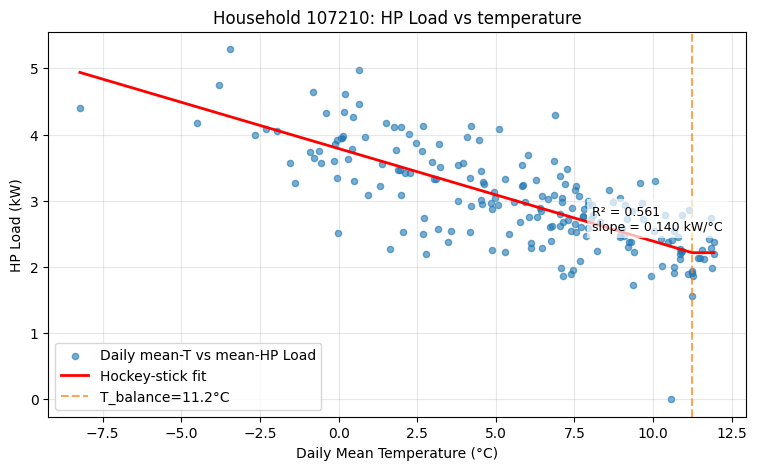

In [12]:
def plot_hockey_stick_example(household_id, load_col, label,
                              heapo_obj, datarange_df, start_date, end_date,
                              coeffs_df=None):
    """Plot data + fitted hockey-stick curve for one household."""
    sm_data = heapo_obj.load_smart_meter_data(household_id, resolution='15min')
    weather_data = heapo_obj.load_weather_data(
        datarange_df.loc[household_id, 'Weather_ID'], resolution='hourly')

    sm_data = sm_data.dropna(subset=[load_col])
    sm_data = sm_data[(sm_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
                      (sm_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))][['Timestamp', load_col]]
    sm_data = sm_data.set_index('Timestamp').resample('1h').sum()

    weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
    weather_data = weather_data[(weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
                                (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))][['Timestamp', 'Temperature_avg_hourly']]
    weather_data = weather_data.set_index('Timestamp')#.resample('15min').mean().interpolate(method='time')

    load_series = sm_data[load_col] * 4
    temp_series  = weather_data['Temperature_avg_hourly']
    x, y = daily_mean_mean_heating_season(temp_series, load_series, HEATING_SEASON_THRESH)

    base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

    x_hat = np.linspace(x.min(), x.max(), 200)
    y_hat = hockey_stick(x_hat, base_load, hp_sensitivity, T_balance)

    plt.figure(figsize=(9, 5))
    plt.scatter(x, y, s=20, alpha=0.6, label=f'Daily mean-T vs mean-{label}')
    plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
    plt.axvline(T_balance, color='tab:orange', ls='--', alpha=0.7, label=f'T_balance={T_balance:.1f}°C')
    plt.xlabel('Daily Mean Temperature (°C)')
    plt.ylabel(f'{label} (kW)')
    plt.title(f'Household {household_id}: {label} vs temperature')
    plt.legend(); plt.grid(alpha=0.3)
    plt.text(0.78, 0.55, f'R² = {r2:.3f}\nslope = {hp_sensitivity:.3f} kW/°C',
             transform=plt.gca().transAxes, fontsize=9, va='top',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.show()


example_id = datarangeDf.index[0]

plot_hockey_stick_example(example_id, 'kWh_received_HeatPump', 'HP Load',
                          heapo, datarangeDf, start_date, end_date,
                          coeffs_df=hockey_coeffs_hp_df)


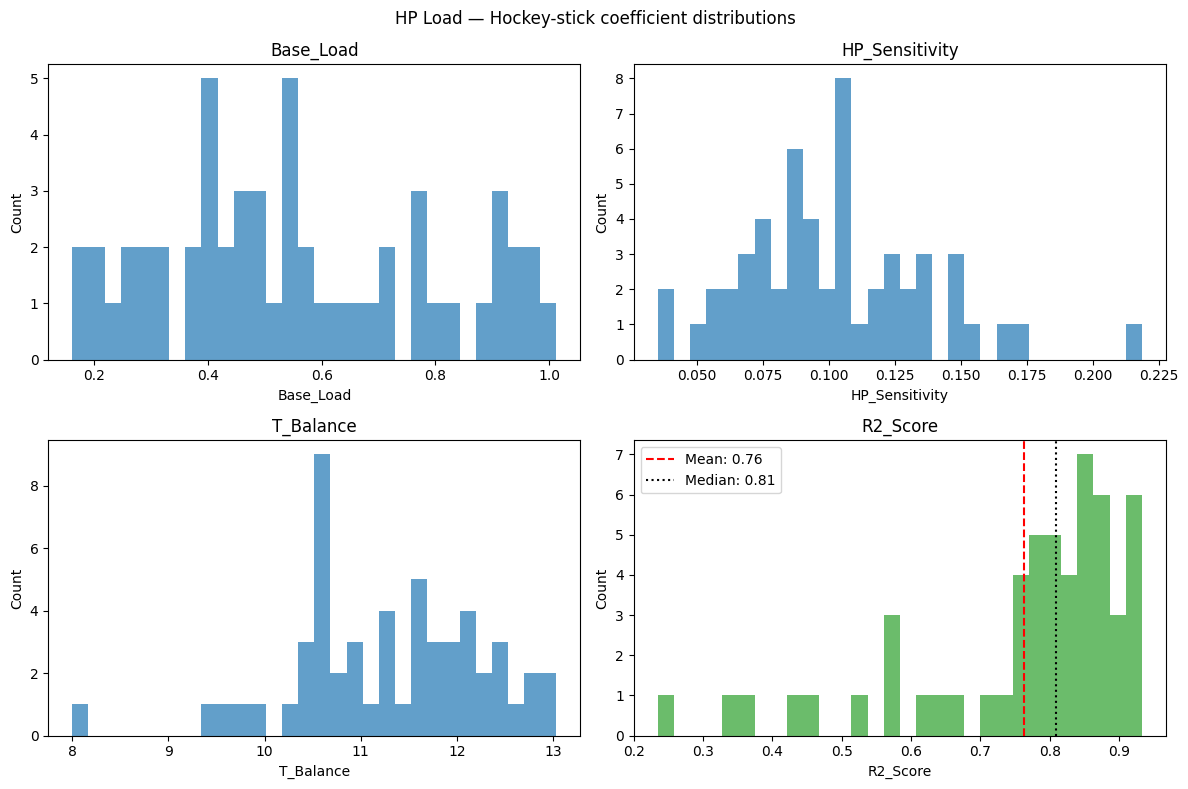

In [13]:
def plot_hockey_stick_histograms(coeffs_df, title_prefix):
    """Plot distribution of hockey-stick coefficients and R² scores."""
    cols = ['Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.flatten()
    for i, col in enumerate(cols):
        ser = coeffs_df[col].dropna()
        ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]
        axs[i].hist(ser, bins=30, color='tab:blue' if col != 'R2_Score' else 'tab:green', alpha=0.7)
        axs[i].set_title(col)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('Count')
        if col == 'R2_Score':
            axs[i].axvline(ser.mean(),   color='red',   ls='--', lw=1.5, label=f'Mean: {ser.mean():.2f}')
            axs[i].axvline(ser.median(), color='black', ls=':',  lw=1.5, label=f'Median: {ser.median():.2f}')
            axs[i].legend()
    fig.suptitle(f'{title_prefix} — Hockey-stick coefficient distributions')
    fig.tight_layout()
    plt.show()


plot_hockey_stick_histograms(hockey_coeffs_hp_df, 'HP Load')


### Fit household smart-meter (total) load vs temperature (hockey-stick model)

In [14]:
sm_fit_results = [
    fit_household_hockey_stick(hid, 'kWh_received_Total',
                               heapo, datarangeDf, start_date, end_date)
    for hid in tqdm(datarangeDf.index, desc='Hockey-stick fit: SM total load')
]
sm_fit_results = [r for r in sm_fit_results if r is not None]

hockey_coeffs_sm_df = pd.DataFrame(
    sm_fit_results,
    columns=['Household_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
).set_index('Household_ID')


Hockey-stick fit: SM total load: 100%|██████████| 57/57 [00:27<00:00,  2.10it/s]


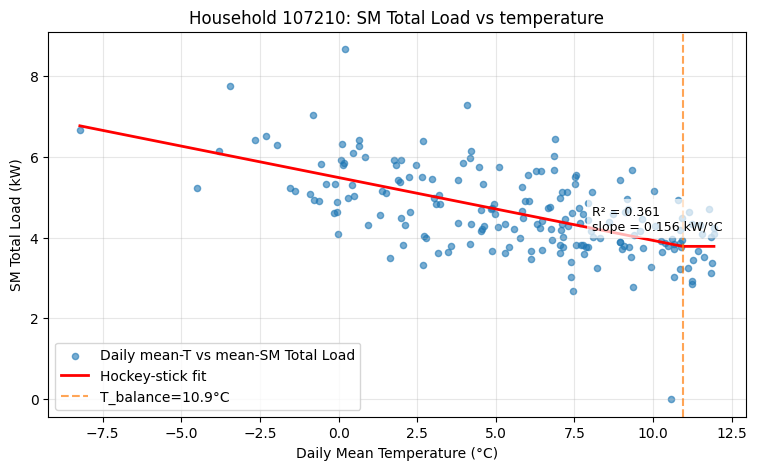

In [15]:
plot_hockey_stick_example(example_id, 'kWh_received_Total', 'SM Total Load',
                          heapo, datarangeDf, start_date, end_date,
                          coeffs_df=hockey_coeffs_sm_df)


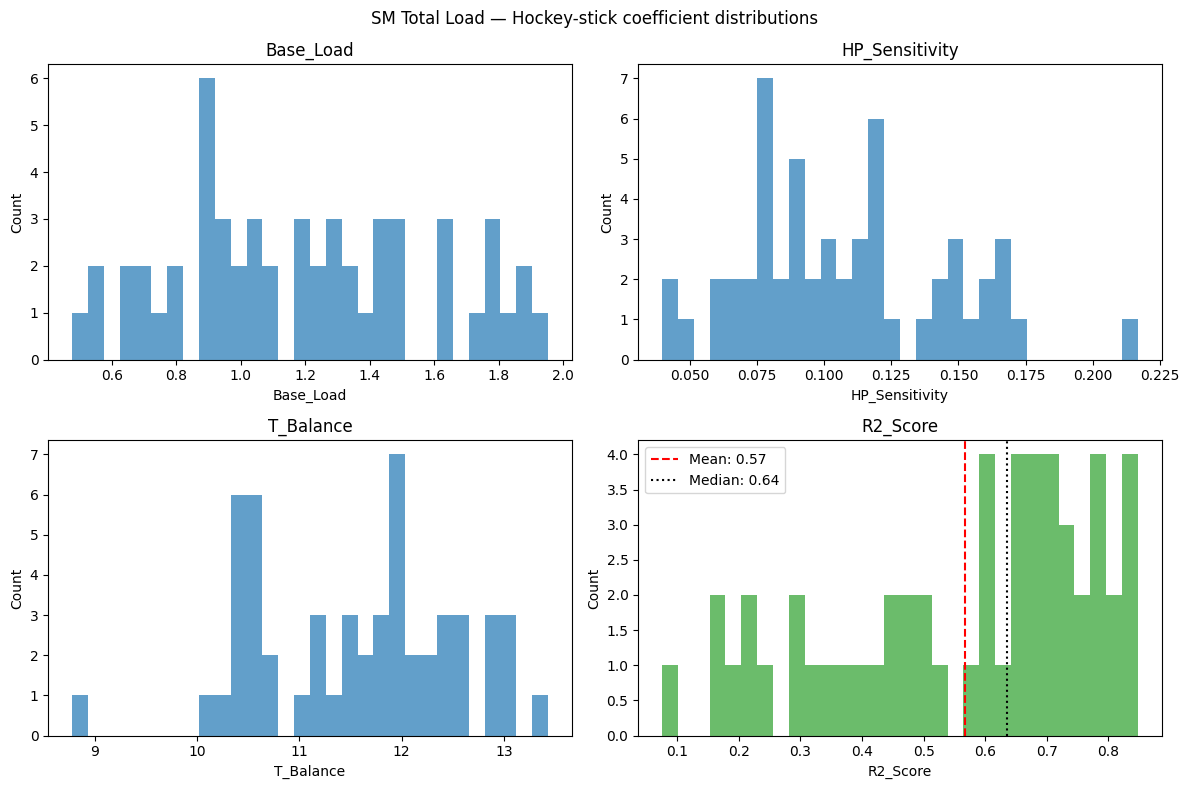

In [16]:
plot_hockey_stick_histograms(hockey_coeffs_sm_df, 'SM Total Load')


### Create synthetic substations

In [17]:
all_smd = heapo.load_smart_meter_data_multiple(datarangeDf.index.tolist(), resolution='15min')
all_smd = all_smd[(all_smd['Timestamp'] >= pd.to_datetime(start_date)) & (all_smd['Timestamp'] <= pd.to_datetime(end_date))]
# all_smd = all_smd[all_smd['Timestamp'].dt.weekday < 5]        # only consider weekdays

In [18]:
if regenerate_substations:
    n_substations = 2000

    substations = {}

    min_substation_size = 20
    max_substation_size = 100

    available_households = list(datarangeDf.index)
    available_weather_ids = list(datarangeDf['Weather_ID'])

    datetime_range = pd.date_range(start=start_date, end=end_date, freq='15min')
    # datetime_range = datetime_range[datetime_range.weekday < 5]  # only consider weekdays

    for i in trange(n_substations, desc='Generating substations'):

        hp_ratio = uniform(0.1, 1.0) # ratio of households with heat pump in substation
        substation_size = randint(min_substation_size, max_substation_size) # number of households in substation

        n_hps = int(hp_ratio * substation_size)

        substations[i] = {
            'size': substation_size,
            'HP_ratio': hp_ratio,
        }

        weather_station = sample(available_weather_ids, 1)[0] # randomly select weather station
        substations[i]['weather_id'] = weather_station

        households_hp = datarangeDf[datarangeDf['Weather_ID'] == weather_station].sample(n_hps, replace=True).index.tolist() # randomly select households with this weather station
        substations[i]['households_hp'] = households_hp

        households = datarangeDf.sample(substation_size - n_hps, replace=True).index.tolist()
        substations[i]['households'] = households

        substations[i]['HP_Load'] = pd.Series(0, index=datetime_range)
        substations[i]['Total_Load'] = pd.Series(0, index=datetime_range)

        for household_id in households_hp:
            smd_hp = all_smd[all_smd['Household_ID'] == household_id]
            smd_hp = smd_hp.set_index('Timestamp')
            smd_hp = smd_hp.sort_index()
            substations[i]['HP_Load'] += smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)
            substations[i]['Total_Load'] += smd_hp['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0) + smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)

        for household_id in households:
            smd = all_smd[all_smd['Household_ID'] == household_id]
            smd = smd.set_index('Timestamp')
            smd = smd.sort_index()
            substations[i]['Total_Load'] += smd['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0)

        substations[i]['HP_Load'] = substations[i]['HP_Load'] * 4 # convert to kW
        substations[i]['Total_Load'] = substations[i]['Total_Load'] * 4 # convert to kW

        weather_data = heapo.load_weather_data(weather_station, resolution='hourly')
        weather_data = weather_data[(weather_data['Timestamp'] >= pd.to_datetime(start_date)) & (weather_data['Timestamp'] <= pd.to_datetime(end_date))][['Timestamp', 'Temperature_avg_hourly']]
        # weather_data = weather_data[weather_data['Timestamp'].dt.weekday < 5]        # only consider weekdays
        weather_data = weather_data.set_index('Timestamp')
        weather_data = weather_data.resample('15min').interpolate(method='time')

        substations[i]['Temperature'] = weather_data['Temperature_avg_hourly']

        substations[i]['HP_Peak'] = np.sum([hp_peaks_df[hp_peaks_df['Household_ID'] == household_id]['HP_Peak'].values[0] for household_id in households_hp])

    # Save substations data
    substations_df = pd.DataFrame.from_dict(substations, orient='index')
    pickle.dump(substations_df, open('data/substations_data.pkl', 'wb'))
else:
    substations_df = pickle.load(open('data/substations_data.pkl', 'rb'))

In [19]:
substations_df = substations_df.fillna(0)
substations_df_train, substations_df_test = train_test_split(substations_df, test_size=0.5, random_state=42)

### Fite piecewise function to substation net load

In [113]:
piece_lin_coeff_sub = []
r2_score_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model for substations'):
    try:
        x, y = daily_mean_mean_heating_season(
            substations_df_train.loc[id, 'Temperature'],
            substations_df_train.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_sub.append((id, r2))
        piece_lin_coeff_sub.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations: 100%|██████████| 1000/1000 [00:05<00:00, 168.46it/s]


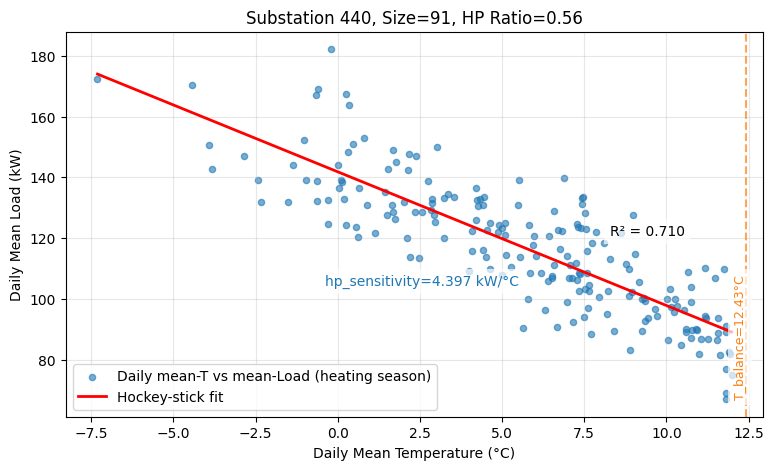

In [117]:
cols = ['Base_Load', 'HP_Sensitivity', 'T_Balance']

piece_lin_coeff_train_df = pd.DataFrame(piece_lin_coeff_sub, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_train_df.set_index('Substation_ID', inplace=True)

r2_score_train_df = pd.DataFrame(r2_score_sub, columns=['Substation_ID', 'R2_Score'])
r2_score_train_df.set_index('Substation_ID', inplace=True)

# example plot with one substation and the fitted hockey-stick curve
i = 0
example_id = int(piece_lin_coeff_train_df.index.values[i])

x, y = daily_mean_mean_heating_season(
    substations_df_train.loc[example_id, 'Temperature'],
    substations_df_train.loc[example_id, 'Total_Load'],
    heating_season_thresh=HEATING_SEASON_THRESH
)

base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = hockey_stick(x_hat, base_load, hp_sensitivity, T_balance)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily mean-T vs mean-Load (heating season)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
plt.xlabel('Daily Mean Temperature (°C)')
plt.ylabel('Daily Mean Load (kW)')
plt.title(f"Substation {example_id}, Size={substations_df_train.loc[example_id, 'size']}, "
          f"HP Ratio={substations_df_train.loc[example_id, 'HP_ratio']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.78, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.axvline(T_balance, color='tab:orange', linestyle='--', alpha=0.7)
plt.text(T_balance, y.min(), f'T_balance={T_balance:.2f}°C', color='tab:orange', fontsize=9,
         rotation=90, ha='right', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text((x.min() + T_balance) / 2, y_hat.max() * 0.6, f'hp_sensitivity={hp_sensitivity:.3f} kW/°C',
         color='tab:blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

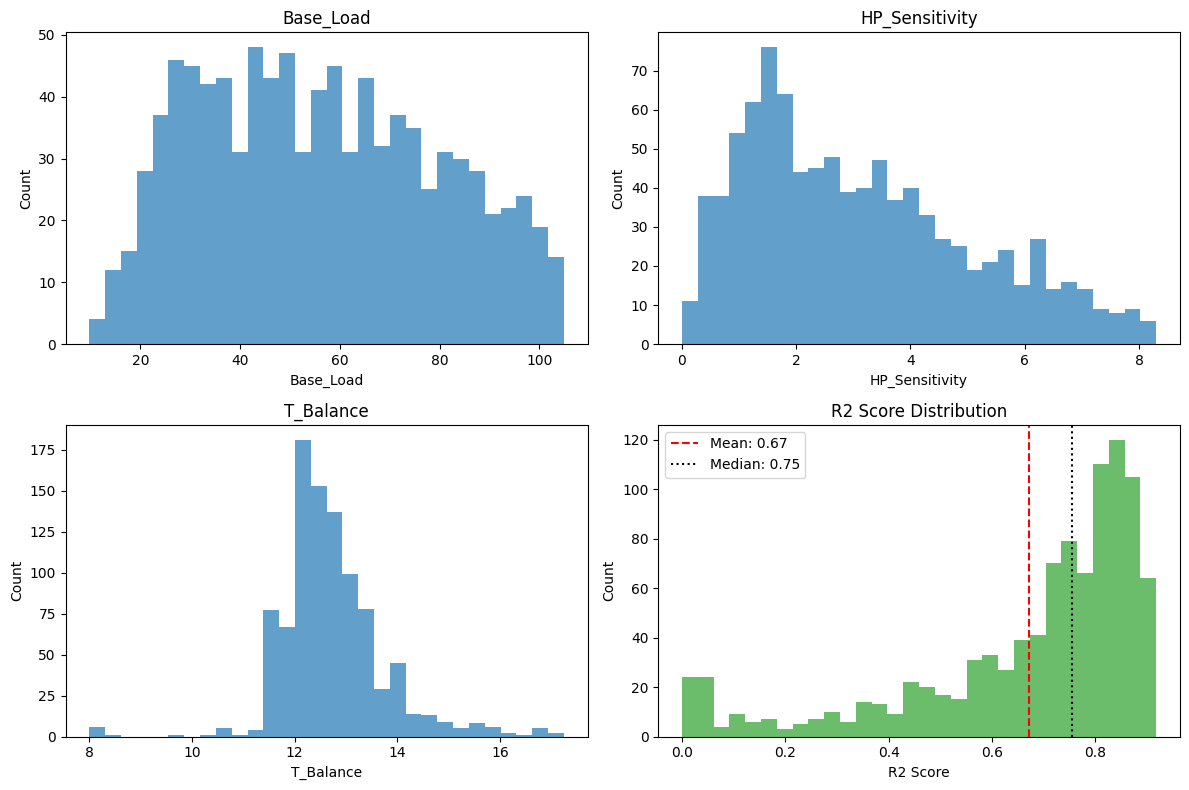

In [115]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeff_train_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')


r2_scores = r2_score_train_df['R2_Score'].dropna()
ax = axs[i+1]
ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

In [118]:
# Extend hockey-stick until simultaneity factor == 1 (per-substation)
res = []

for sid in piece_lin_coeff_train_df.index:
    try:
        hp_sens = float(piece_lin_coeff_train_df.at[sid, 'HP_Sensitivity'])
        T_balance = float(piece_lin_coeff_train_df.at[sid, 'T_Balance'])
    except Exception:
        res.append((sid, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
        continue

    # get non-simultaneous capacity and simultaneous observed peak
    if sid not in substations_df.index:
        res.append((sid, hp_sens, np.nan, np.nan, np.nan, np.nan, T_balance))
        continue

    hp_peak_total = substations_df.at[sid, 'HP_Peak'] if 'HP_Peak' in substations_df.columns else np.nan
    hp_load_series = substations_df.at[sid, 'HP_Load'] if 'HP_Load' in substations_df.columns else None

    if hp_load_series is None or hp_peak_total is None or hp_peak_total == 0 or hp_load_series.empty:
        res.append((sid, hp_sens, hp_peak_total, np.nan, np.nan, np.nan, T_balance))
        continue

    simult_peak = float(hp_load_series.max())
    # observed simultaneity factor at time of simult_peak
    sf_obs = simult_peak / hp_peak_total if hp_peak_total != 0 else np.nan

    # reference temperature at simult_peak timestamp
    try:
        ts_peak = hp_load_series.idxmax()
        T_ref = float(substations_df.at[sid, 'Temperature'].loc[ts_peak])
    except Exception:
        # fallback: use balance temperature as reference
        T_ref = T_balance

    # slope of simultaneity factor vs T: assume same relative change as power:
    # when T decreases by 1°C total simultaneous power increases by hp_sens (kW),
    # so simultaneity factor increases by hp_sens / hp_peak_total (unitless per °C)
    m = hp_sens / hp_peak_total if hp_peak_total != 0 else np.nan

    if np.isfinite(m) and m != 0:
        # solve SF(T_target) = 1  ->  1 = SF_obs + m * (T_ref - T_target)
        T_target = T_ref - (1.0 - sf_obs) / m
    else:
        T_target = np.nan

    res.append((sid, hp_sens, hp_peak_total, simult_peak, sf_obs, T_ref, T_target, T_balance))

cols = ['Substation_ID', 'HP_Sensitivity', 'HP_Peak', 'Simult_HP_Peak', 'SF_obs', 'T_ref', 'T_target', 'T_Balance']
sf_df = pd.DataFrame(res, columns=cols).set_index('Substation_ID')

# show results for substations with finite target temperature
display(sf_df.sort_values('T_target').head(50))

,HP_Sensitivity,HP_Peak,Simult_HP_Peak,SF_obs,T_ref,T_target,T_Balance
Substation_ID,,,,,,,
1155,6.882375e-10,33.668,28.620,0.850065,-1.900,-7.334677e+09,19.999721
1171,4.939254e-03,53.028,45.024,0.849061,0.800,-1.619688e+03,15.888668
1775,2.232446e-01,303.012,257.580,0.850065,-1.900,-2.054077e+02,13.815963
1253,1.960688e-01,104.396,87.060,0.833940,-1.900,-9.031794e+01,13.365531
653,5.512475e-01,297.480,251.980,0.847049,-1.900,-8.444005e+01,13.630006
1466,1.426856e-01,69.204,57.920,0.836946,-1.900,-8.098296e+01,8.000000
1183,7.981498e-01,354.944,296.400,0.835061,-1.900,-7.524964e+01,19.999996
918,9.397048e-02,39.408,32.520,0.825213,-1.900,-7.519961e+01,13.407121
356,4.795467e-01,63.948,35.852,0.560643,-11.500,-7.008866e+01,13.349648


R² for HP_Sensitivity vs Simultaneous HP Peak: 0.655
42.824, 3.435
R² for HP_Sensitivity_per_peak vs Simultaneous HP Peak: 0.071


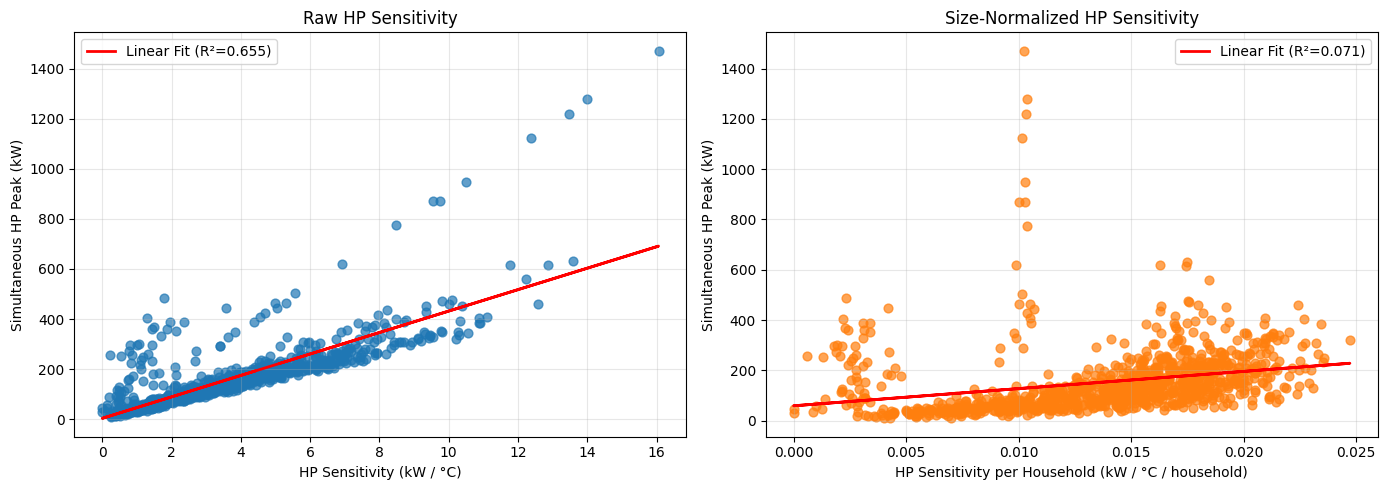

In [101]:
substations_df_train['Simult_HP_Peak'] = [substations_df_train.iloc[i]['HP_Load'].max() if hp_ratio > 0 else 0 for i, hp_ratio in enumerate(substations_df_train['HP_ratio'])]

data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['Simult_HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

lin = LinearRegression()
lin.fit(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
r2 = lin.score(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity vs Simultaneous HP Peak: {r2:.3f}")
print(f"{lin.coef_[0]:.3f}, {lin.intercept_:.3f}")

lin_norm = LinearRegression()
lin_norm.fit(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
r2_norm = lin_norm.score(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity_per_peak vs Simultaneous HP Peak: {r2_norm:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(data['HP_Sensitivity'], data['Simult_HP_Peak'], alpha=0.7, s=40)
axs[0].plot(data['HP_Sensitivity'], lin.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2:.3f})')
axs[0].set_xlabel('HP Sensitivity (kW / °C)')
axs[0].set_ylabel('Simultaneous HP Peak (kW)')
axs[0].set_title('Raw HP Sensitivity')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].scatter(data['HP_Sensitivity_per_peak'], data['Simult_HP_Peak'], alpha=0.7, s=40, color='tab:orange')
axs[1].plot(data['HP_Sensitivity_per_peak'], lin_norm.predict(data[['HP_Sensitivity_per_peak']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2_norm:.3f})')
axs[1].set_xlabel('HP Sensitivity per Household (kW / °C / household)')
axs[1].set_ylabel('Simultaneous HP Peak (kW)')
axs[1].set_title('Size-Normalized HP Sensitivity')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Non-Simultaneous HP Peak: 0.856
63.070, 11.106


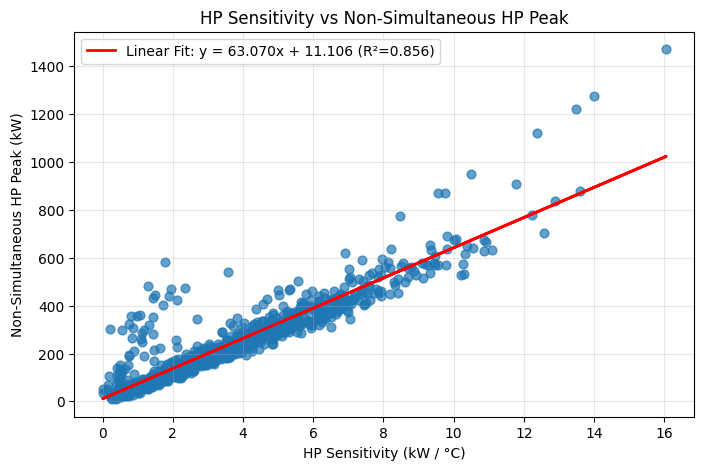

In [102]:
data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

nonSimDeltaFit = LinearRegression()
nonSimDeltaFit.fit(data[['HP_Sensitivity']], data['HP_Peak'])
r2 = nonSimDeltaFit.score(data[['HP_Sensitivity']], data['HP_Peak'])
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak: {r2:.3f}")
print(f"{nonSimDeltaFit.coef_[0]:.3f}, {nonSimDeltaFit.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['HP_Sensitivity'], data['HP_Peak'], alpha=0.7, s=40)
plt.plot(data['HP_Sensitivity'], nonSimDeltaFit.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [103]:
piece_lin_coeff_test = []
r2_score_test = []

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model for substations (test)'):
    try:
        x, y = daily_mean_mean_heating_season(
            substations_df_test.loc[id, 'Temperature'],
            substations_df_test.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_test.append((id, r2))
        piece_lin_coeff_test.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations (test): 100%|██████████| 1000/1000 [00:08<00:00, 122.18it/s]


In [104]:
piece_lin_coeff_test_df = pd.DataFrame(piece_lin_coeff_test, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_test_df.set_index('Substation_ID', inplace=True)

r2_score_test_df = pd.DataFrame(r2_score_test, columns=['Substation_ID', 'R2_Score'])
r2_score_test_df.set_index('Substation_ID', inplace=True)

In [105]:
piece_lin_coeff_df = pd.concat([piece_lin_coeff_train_df, piece_lin_coeff_test_df])
r2_score_df = pd.concat([r2_score_train_df, r2_score_test_df])

R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: 0.864


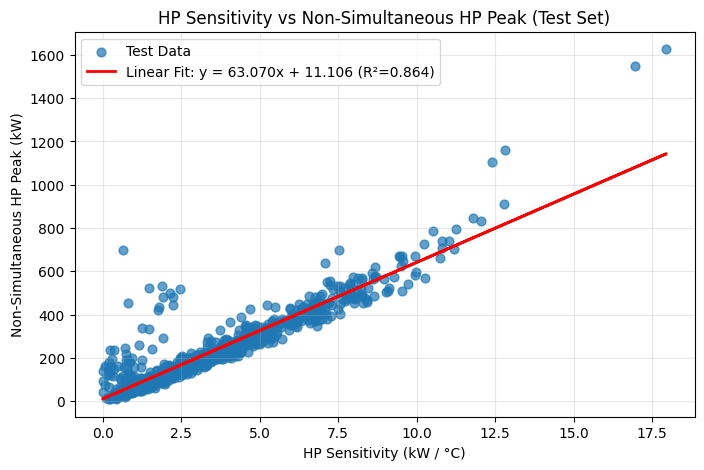

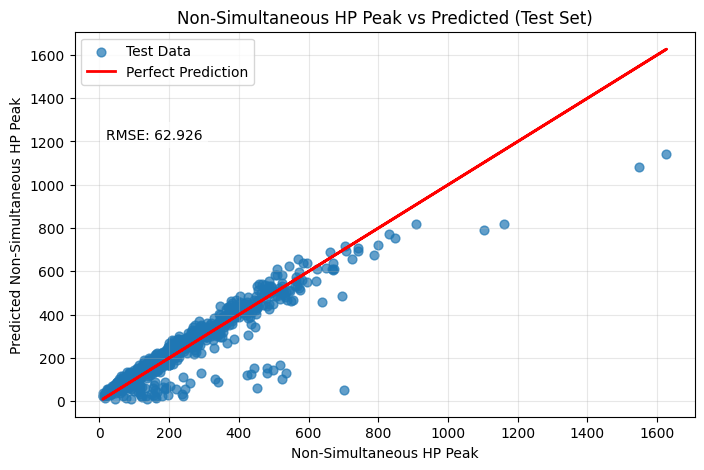

In [106]:
data_test = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test[['HP_Peak']], how='inner')

nonSimTestPred = nonSimDeltaFit.predict(data_test[['HP_Sensitivity']])
r2_nonSimTest = r2_score(data_test['HP_Peak'], nonSimTestPred)
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: {r2_nonSimTest:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Sensitivity'], data_test['HP_Peak'], alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Sensitivity'], nonSimTestPred, color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2_nonSimTest:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak (Test Set)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Peak'], nonSimTestPred, alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Peak'], data_test['HP_Peak'], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Non-Simultaneous HP Peak')
plt.ylabel('Predicted Non-Simultaneous HP Peak')
plt.title('Non-Simultaneous HP Peak vs Predicted (Test Set)')
plt.text(0.05, 0.75, f'RMSE: {np.sqrt(mean_squared_error(data_test["HP_Peak"], nonSimTestPred)):.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

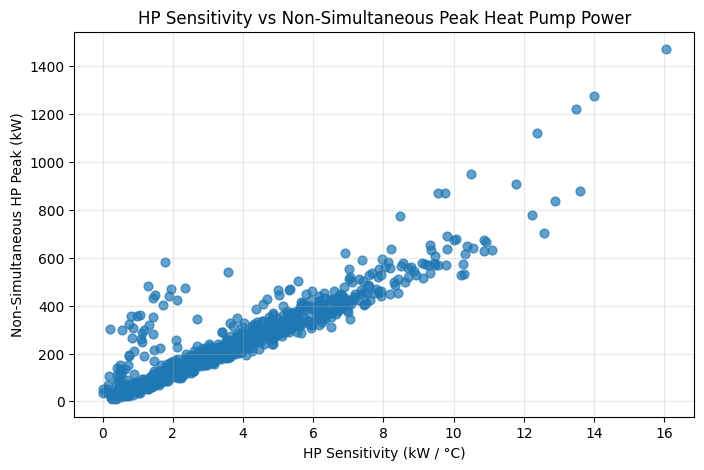

In [107]:
data_plot = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner')

plt.figure(figsize=(8, 5))
plt.scatter(data_plot['HP_Sensitivity'], data_plot['HP_Peak'], alpha=0.7, s=40)
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
plt.grid(alpha=0.3)
plt.show()

Training R² (weighted): 0.925
Test R²: 0.859
Test RMSE: 64.157 kW
Test MAPE: 16.42%
Linear model: HP_Peak = 67.159 * HP_Sensitivity + -14.025


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


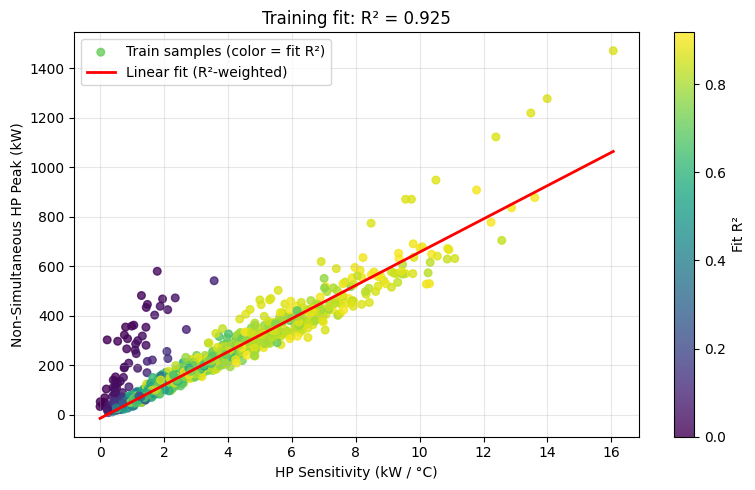

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


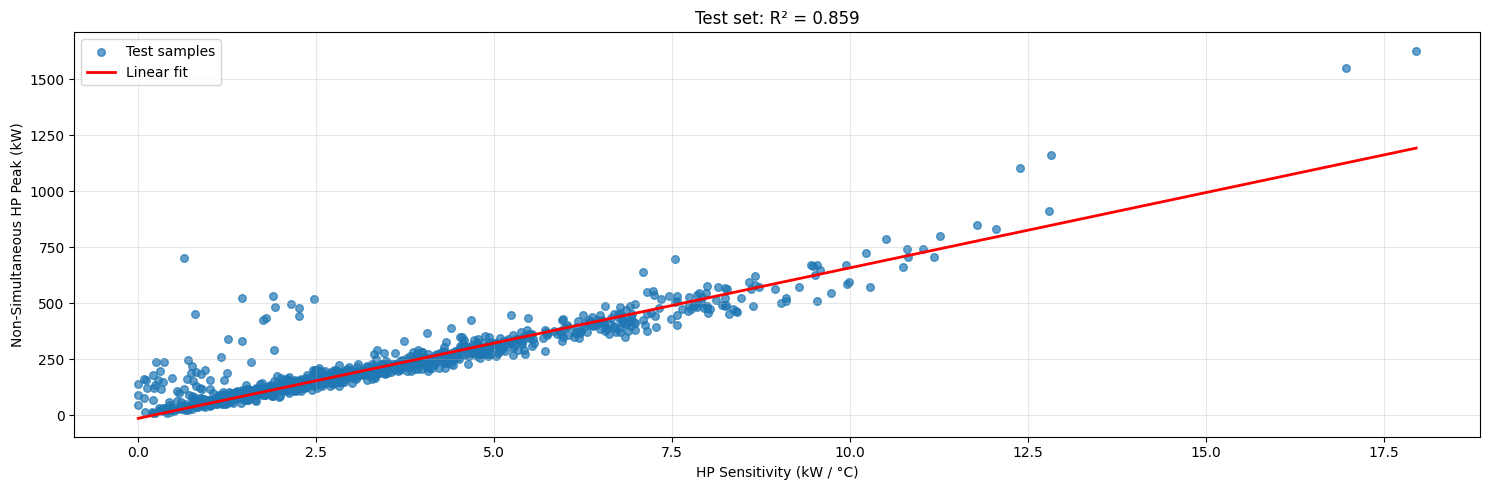

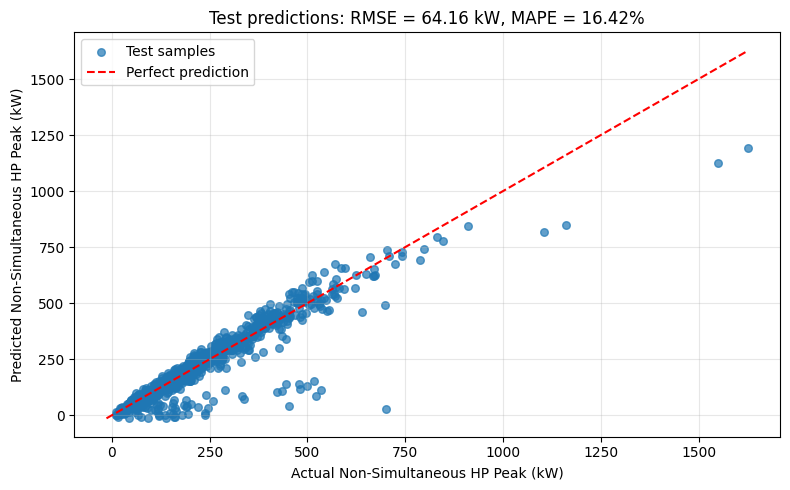

In [108]:
train_data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner').join(r2_score_train_df, how='inner').dropna()

# FIX: weight samples by fit quality (R²) instead of using a hard
# accept/reject threshold -- substations with a noisy/uncertain
# hockey-stick fit contribute less to the regression rather than being
# discarded outright.
sample_weight_train = train_data['R2_Score'].clip(0, 1)

modelLinSlope = LinearRegression()
modelLinSlope.fit(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)

test_data = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test['HP_Peak'], how='inner').dropna()
test_data['Predicted_HP_Peak'] = modelLinSlope.predict(test_data[['HP_Sensitivity']])

r2_train = modelLinSlope.score(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)
r2_test = r2_score(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
rmse_test = root_mean_squared_error(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
small_y_threshold = 10.0
mask = test_data['HP_Peak'].abs() > small_y_threshold
mape_test = mean_absolute_percentage_error(
    test_data.loc[mask, 'HP_Peak'],
    test_data.loc[mask, 'Predicted_HP_Peak']
) * 100

print(f"Training R² (weighted): {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f} kW")
print(f"Test MAPE: {mape_test:.2f}%")
print(f"Linear model: HP_Peak = {modelLinSlope.coef_[0]:.3f} * HP_Sensitivity + {modelLinSlope.intercept_:.3f}")

# Plot training set, colored by fit R² (the sample weight)
fig_train, ax_train = plt.subplots(figsize=(8, 5))
sc = ax_train.scatter(train_data['HP_Sensitivity'], train_data['HP_Peak'], c=sample_weight_train, cmap='viridis', alpha=0.8, s=30, label='Train samples (color = fit R²)')
x_line = np.linspace(train_data['HP_Sensitivity'].min(), train_data['HP_Sensitivity'].max(), 100)
ax_train.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit (R²-weighted)')
ax_train.set_xlabel('HP Sensitivity (kW / °C)')
ax_train.set_ylabel('Non-Simultaneous HP Peak (kW)')
ax_train.set_title(f'Training fit: R² = {r2_train:.3f}')
ax_train.grid(alpha=0.3)
ax_train.legend()
fig_train.colorbar(sc, ax=ax_train, label='Fit R²')
fig_train.tight_layout()
plt.show()

fig, axs = plt.subplots(figsize=(15, 5))
axs.scatter(test_data['HP_Sensitivity'], test_data['HP_Peak'], alpha=0.7, s=30, label='Test samples')
x_line = np.linspace(test_data['HP_Sensitivity'].min(), test_data['HP_Sensitivity'].max(), 100)
axs.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit')
axs.set_xlabel('HP Sensitivity (kW / °C)')
axs.set_ylabel('Non-Simultaneous HP Peak (kW)')
axs.set_title(f'Test set: R² = {r2_test:.3f}')
axs.grid(alpha=0.3)
axs.legend()
fig.tight_layout()
plt.show()

# Plot test set predictions vs actual
min_val = min(test_data['HP_Peak'].min(), test_data['Predicted_HP_Peak'].min())
max_val = max(test_data['HP_Peak'].max(), test_data['Predicted_HP_Peak'].max())

fig_test, ax_test = plt.subplots(figsize=(8, 5))
ax_test.scatter(test_data['HP_Peak'], test_data['Predicted_HP_Peak'], alpha=0.7, s=30, label='Test samples')
ax_test.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax_test.set_xlabel('Actual Non-Simultaneous HP Peak (kW)')
ax_test.set_ylabel('Predicted Non-Simultaneous HP Peak (kW)')
ax_test.set_title(f'Test predictions: RMSE = {rmse_test:.2f} kW, MAPE = {mape_test:.2f}%')
ax_test.grid(alpha=0.3)
ax_test.legend()
fig_test.tight_layout()
plt.show()

### Fit piecewise function to time-of-day indexed data

In [31]:
# FIX: previously fit 24 separate unconstrained 2-segment pwlf models per
# substation (one per hour), producing 120 often-noisy coefficients and
# visibly degenerate fits (S1 < -1000 outliers, see the diagnostic below).
# Instead, pool hours into 4 broader time-of-day windows and fit the same
# constrained hockey-stick model used for the daily fit above.
hour_groups = {
    'Night':     list(range(0, 6)),
    'Morning':   list(range(6, 12)),
    'Afternoon': list(range(12, 18)),
    'Evening':   list(range(18, 24)),
}

piece_lin_coeff_hourly = {}
r2_score_hourly = {}

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_train.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_train.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly[id] = {}
        r2_score_hourly[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly[id][group_name] = r2

    except Exception:
        pass

Fitting hockey-stick model by time-of-day window: 100%|██████████| 1000/1000 [00:21<00:00, 47.50it/s]


In [32]:
piece_lin_coeff_hourly_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly, orient='index')
piece_lin_coeff_hourly_df.index.name = 'Substation_ID'

r2_score_hourly_df = pd.DataFrame.from_dict(r2_score_hourly, orient='index')
r2_score_hourly_df.index.name = 'Substation_ID'

sensitivity_cols = [c for c in piece_lin_coeff_hourly_df.columns if c.endswith('_Sensitivity')]

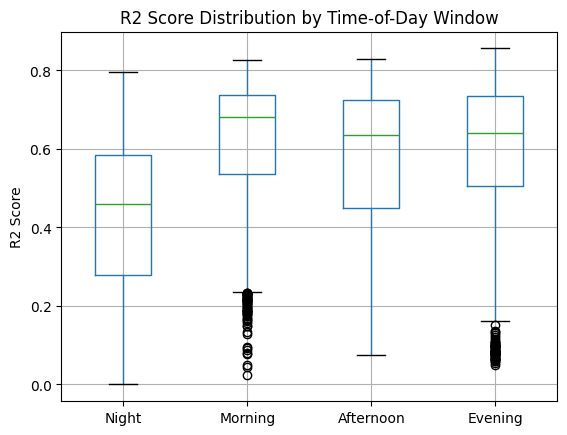

In [33]:
r2_score_hourly_df.boxplot()
plt.title('R2 Score Distribution by Time-of-Day Window')
plt.ylabel('R2 Score')
plt.show()

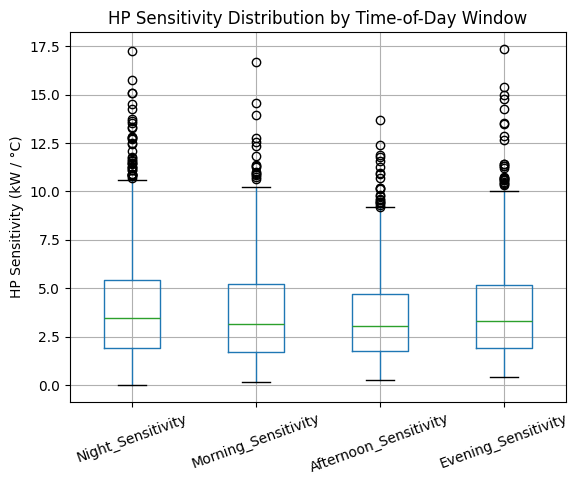

In [34]:
piece_lin_coeff_hourly_df[sensitivity_cols].boxplot()
plt.title('HP Sensitivity Distribution by Time-of-Day Window')
plt.ylabel('HP Sensitivity (kW / °C)')
plt.xticks(rotation=20)
plt.show()

In [35]:
# sensitivity_cols already isolated in cell 46; kept here under the
# original variable name for continuity with anything downstream.
piece_lin_coeff_hourly_df_s1 = piece_lin_coeff_hourly_df[sensitivity_cols]
piece_lin_coeff_hourly_df_s1.head()

,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
Substation_ID,,,,
440,4.893046,5.336948,4.596630,4.726284
573,4.123676,3.444076,3.356661,3.785564
946,0.916265,1.091516,1.354633,1.705354
997,4.113563,4.926133,4.168861,4.107127
503,4.143730,5.450327,4.477484,4.723925


In [36]:
# Correlation of each time-window's HP sensitivity with HP_Peak.
combined_df = piece_lin_coeff_hourly_df[sensitivity_cols].join(substations_df_train['HP_Peak'])

correlation_matrix = combined_df.corr()
hp_peak_correlations = correlation_matrix['HP_Peak'].drop('HP_Peak')

print("Correlation of time-window HP Sensitivity with HP_Peak:")
display(hp_peak_correlations.to_frame().T.style.background_gradient(cmap='RdYlGn', axis=1))

Correlation of time-window HP Sensitivity with HP_Peak:


,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
HP_Peak,0.925710,0.938835,0.941531,0.952557


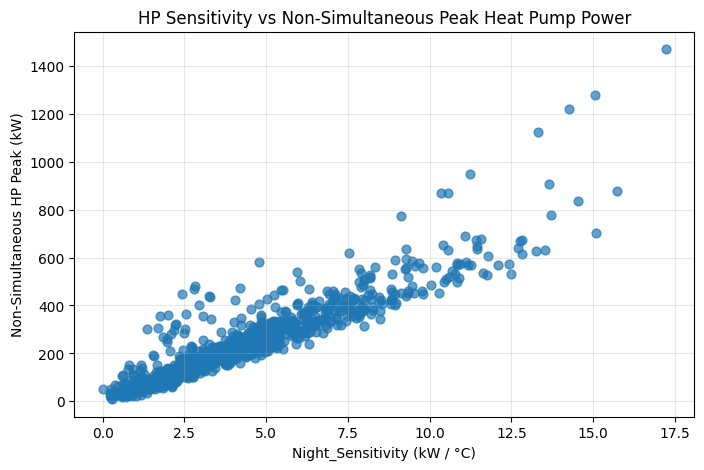

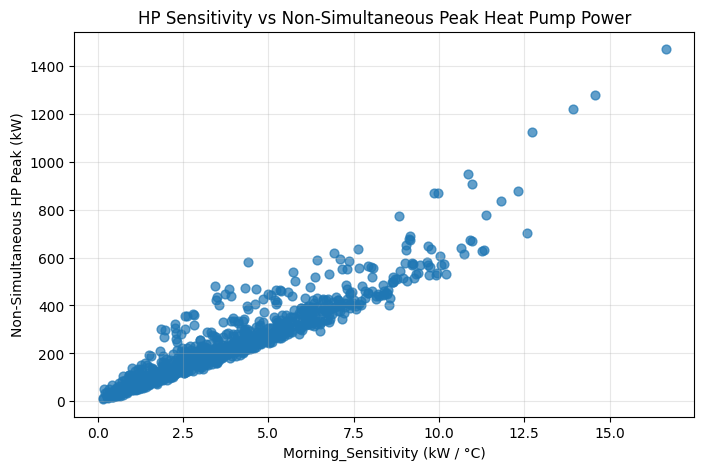

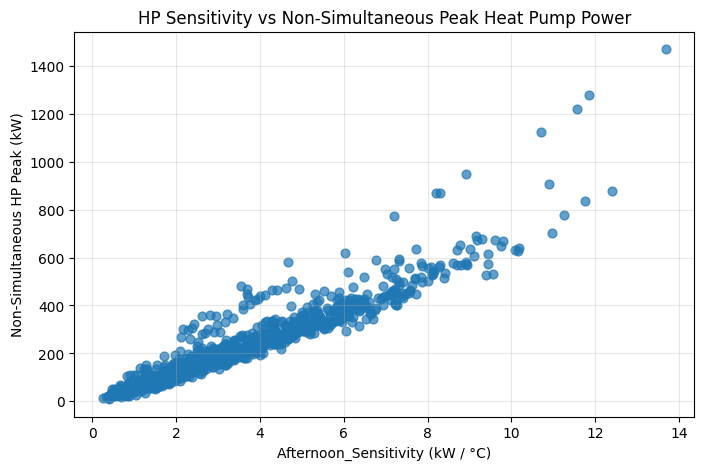

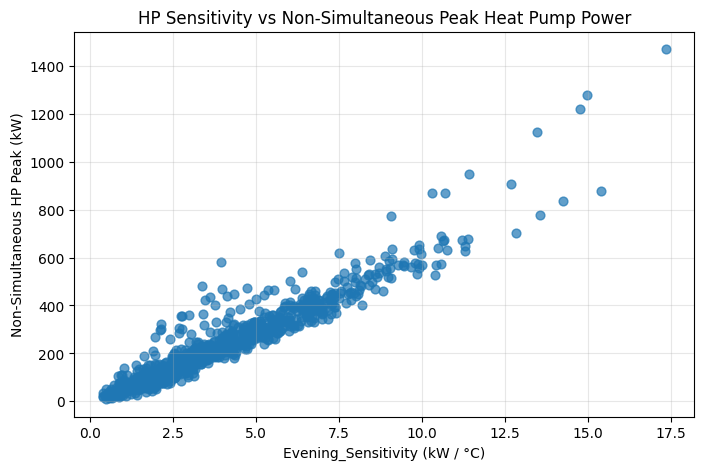

In [37]:
for col in sensitivity_cols:
    plt.figure(figsize=(8, 5))
    plt.scatter(combined_df[col], combined_df['HP_Peak'], alpha=0.7, s=40)
    plt.xlabel(f'{col} (kW / °C)')
    plt.ylabel('Non-Simultaneous HP Peak (kW)')
    plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
piece_lin_coeff_hourly_test = {}
r2_score_hourly_test = {}

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_test.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_test.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly_test[id] = {}
        r2_score_hourly_test[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly_test[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly_test[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly_test[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly_test[id][group_name] = r2

    except Exception:
        pass

In [39]:
piece_lin_coeff_hourly_test_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly_test, orient='index')
piece_lin_coeff_hourly_test_df.index.name = 'Substation_ID'

r2_score_hourly_test_df = pd.DataFrame.from_dict(r2_score_hourly_test, orient='index')
r2_score_hourly_test_df.index.name = 'Substation_ID'

In [40]:
combined_test_df = piece_lin_coeff_hourly_test_df[sensitivity_cols].join(substations_df_test['HP_Peak'])

Selected Ridge alpha: 2.6827


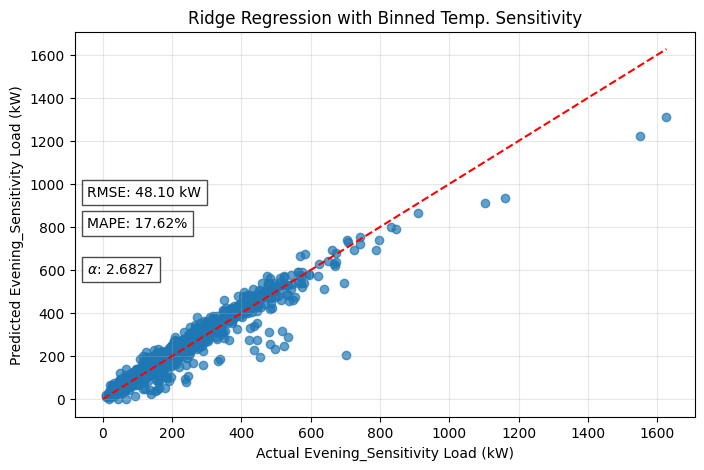

In [142]:
sensitivity_model = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
sensitivity_model.fit(combined_df[sensitivity_cols], combined_df['HP_Peak'])
print(f"Selected Ridge alpha: {sensitivity_model.alpha_:.4f}")

sensitivity_pred = sensitivity_model.predict(combined_test_df[sensitivity_cols])
sensitivity_pred = np.maximum(sensitivity_pred, 0) # ensure no negative predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(combined_test_df['HP_Peak'], sensitivity_pred, alpha=0.7)
ax.plot([0, combined_test_df['HP_Peak'].max()], [0, combined_test_df['HP_Peak'].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Binned Temp. Sensitivity')
mask = combined_test_df['HP_Peak'].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(combined_test_df['HP_Peak'].values[mask], sensitivity_pred[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(combined_test_df['HP_Peak'].values, sensitivity_pred)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {sensitivity_model.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.grid(alpha=0.3)
plt.show()

## Net-Load to Daily Cumulative HDH

### Fit substation net load vs cumulative Heating Degree Hours (HDH)

Parallel to the temperature-based hockey-stick fit above, but the independent
variable is now each day's cumulative Heating Degree Hours (HDH), computed by
summing `max(0, HDH_THRESH - T)` over all sub-daily samples (weighted by
sample duration). Because the zero-clipping hinge is already baked into the
HDH transform itself, a plain 2-parameter line (`base_load + hp_sensitivity *
HDH`) captures the same "flat below threshold / rising above it" shape as the
hockey-stick model, without needing a separate `T_balance` breakpoint.

In [ ]:
# ---------------------------------------------------------------------------
# HDH (Heating Degree Hours) linear model: Load = base_load + hp_sensitivity * HDH
#
# HDH_day = sum over sub-daily samples of max(0, HDH_THRESH - T) * dt_hours
#
# Unlike the raw-temperature hockey-stick fit, the zero-clipping hinge is
# already baked into the HDH transform itself (every sample above the
# threshold contributes 0), so a plain 2-parameter line captures the same
# "flat below threshold / rising above it" shape without a separate
# T_balance / breakpoint parameter.
# ---------------------------------------------------------------------------
HDH_THRESH = 12.0   # degC, threshold for Heating Degree Hour accumulation


def daily_cumulative_hdh(temperature, hdh_thresh=HDH_THRESH, resolution='D'):
    """Cumulative Heating Degree Hours (degC*h) per day.

    Sums max(0, hdh_thresh - T) over each sub-daily sample, weighted by the
    sample's duration in hours, so days with the same mean temperature but
    bigger swings around the threshold get different HDH totals.
    """
    temperature = temperature.sort_index()
    dt_hours = temperature.index.to_series().diff().median().total_seconds() / 3600
    hdh_per_sample = (hdh_thresh - temperature).clip(lower=0) * dt_hours
    return hdh_per_sample.resample(resolution).sum()


def daily_hdh_mean_load(temperature, load, hdh_thresh=HDH_THRESH, resolution='D'):
    """Build (daily_cumulative_HDH, daily_mean_load) pairs."""
    daily_hdh = daily_cumulative_hdh(temperature, hdh_thresh, resolution)
    daily_load_mean = load.resample(resolution).mean()
    sm_data = pd.DataFrame({'HDH': daily_hdh, 'Load_mean': daily_load_mean}).dropna()
    return sm_data['HDH'].values, sm_data['Load_mean'].values


def hdh_linear(hdh, base_load, hp_sensitivity):
    return base_load + hp_sensitivity * hdh


def fit_hdh_linear(x, y):
    """Fit a 2-parameter HDH-vs-load line.

    Returns (base_load, hp_sensitivity, r2). Raises if curve_fit fails so
    callers can catch and skip.
    """
    p0 = [np.median(y), 0.01]
    bounds = ([0, 0], [np.inf, np.inf])
    popt, _ = curve_fit(hdh_linear, x, y, p0=p0, bounds=bounds, maxfev=5000)
    y_pred = hdh_linear(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    base_load, hp_sensitivity = popt
    return base_load, hp_sensitivity, r2

In [ ]:
piece_lin_coeff_hdh_sub = []
r2_score_hdh_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting HDH-linear model for substations'):
    try:
        x, y = daily_hdh_mean_load(
            substations_df_train.loc[id, 'Temperature'],
            substations_df_train.loc[id, 'Total_Load'],
            hdh_thresh=HDH_THRESH
        )

        if np.sum(x > 0) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)

        r2_score_hdh_sub.append((id, r2))
        piece_lin_coeff_hdh_sub.append((id, base_load, hp_sensitivity))

    except Exception:
        pass

Fitting HDH-linear model for substations: 100%|██████████| 1000/1000 [00:06<00:00, 143.71it/s]


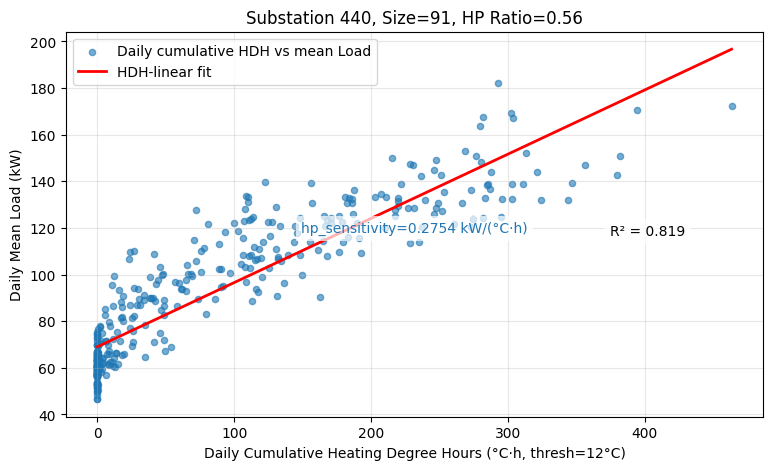

In [ ]:
piece_lin_coeff_hdh_train_df = pd.DataFrame(
    piece_lin_coeff_hdh_sub, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity']
).set_index('Substation_ID')

r2_score_hdh_train_df = pd.DataFrame(
    r2_score_hdh_sub, columns=['Substation_ID', 'R2_Score']
).set_index('Substation_ID')

# example plot with one substation and the fitted HDH-linear curve
i = 0
example_id_hdh = int(piece_lin_coeff_hdh_train_df.index.values[i])

x, y = daily_hdh_mean_load(
    substations_df_train.loc[example_id_hdh, 'Temperature'],
    substations_df_train.loc[example_id_hdh, 'Total_Load'],
    hdh_thresh=HDH_THRESH
)

base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)

x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = hdh_linear(x_hat, base_load, hp_sensitivity)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily cumulative HDH vs mean Load')
plt.plot(x_hat, y_hat, color='red', lw=2, label='HDH-linear fit')
plt.xlabel(f'Daily Cumulative Heating Degree Hours (\u00b0C\u00b7h, thresh={HDH_THRESH:.0f}\u00b0C)')
plt.ylabel('Daily Mean Load (kW)')
plt.title(f"Substation {example_id_hdh}, Size={substations_df_train.loc[example_id_hdh, 'size']}, "
          f"HP Ratio={substations_df_train.loc[example_id_hdh, 'HP_ratio']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.78, 0.5, f'R\u00b2 = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text(x.max() * 0.5, y_hat.max() * 0.6, f'hp_sensitivity={hp_sensitivity:.4f} kW/(\u00b0C\u00b7h)',
         color='tab:blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

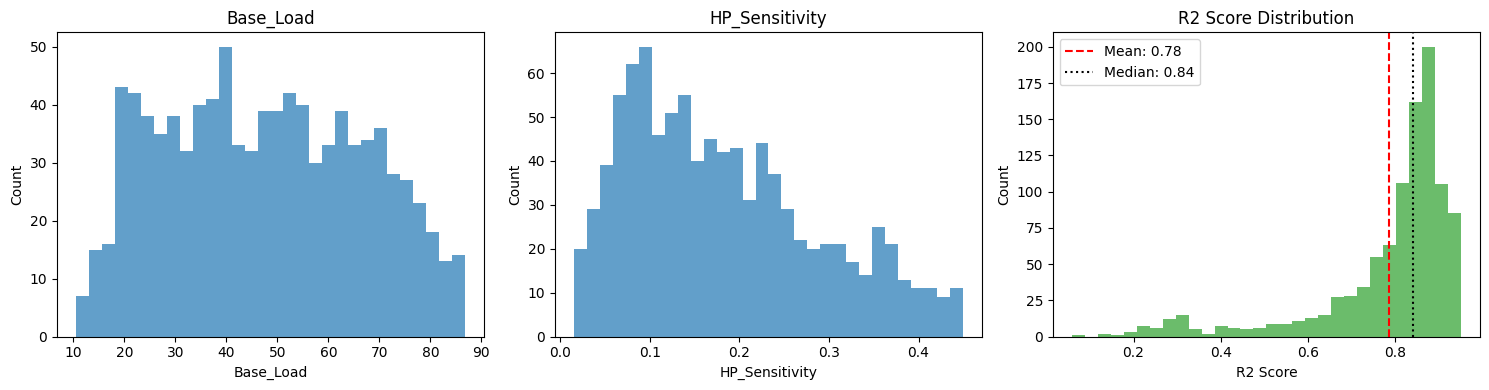

In [ ]:
cols_hdh = ['Base_Load', 'HP_Sensitivity']

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs = axs.flatten()

for i, col in enumerate(cols_hdh):
    ser = piece_lin_coeff_hdh_train_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')

r2_scores_hdh = r2_score_hdh_train_df['R2_Score'].dropna()
ax = axs[2]
ax.hist(r2_scores_hdh, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores_hdh.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores_hdh.mean():.2f}')
ax.axvline(r2_scores_hdh.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores_hdh.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

## Baseline (Peak Net Load = Simultaneous HP Peak Load)

In [42]:
# Baseline cell — see Feature_Max_Max in X_test for a simple peak-load baseline.


## Time Based Features

In [144]:
TIME_FEATURES_PATH = 'data/substations_time_data.pkl'

if regenerate_time_features or not os.path.exists(TIME_FEATURES_PATH):
    substations_time = {}
    resolution = 15        # minutes
    T_base = HEATING_SEASON_THRESH   # use the single global constant

    for i in trange(len(substations_df), desc='Extracting time-of-day features'):
        sub_df     = substations_df.iloc[i]['Total_Load'].resample(f'{resolution}min').mean().ffill()
        weather_df = substations_df.iloc[i]['Temperature'].resample(f'{resolution}min').mean().ffill()

        # weekdays only
        sub_df     = sub_df[sub_df.index.weekday < 5]
        weather_df = weather_df[weather_df.index.weekday < 5]

        daily_load    = (sub_df.to_frame('Total_Load')
                         .assign(Date=sub_df.index.date, Time=sub_df.index.time)
                         .pivot(index='Date', columns='Time', values='Total_Load').ffill())
        daily_weather = (weather_df.to_frame('Temperature')
                         .assign(Date=weather_df.index.date, Time=weather_df.index.time)
                         .pivot(index='Date', columns='Time', values='Temperature').ffill())
        daily_weather = daily_weather[daily_weather.index.isin(daily_load.index)]

        hdh = np.maximum(0, T_base - daily_weather)

        feats = {
            'Mean':        daily_load.mean(axis=0),
            'Std':         daily_load.std(axis=0),
            'Min':         daily_load.min(axis=0),
            'Max':         daily_load.max(axis=0),
            'Skew':        daily_load.skew(axis=0),
            'Kurtosis':    daily_load.kurtosis(axis=0),
            'Max-Min':     daily_load.max(axis=0) - daily_load.min(axis=0),
            'Cov':         np.array([np.cov(daily_load.iloc[:, t],
                                            daily_weather.iloc[:, t])[0][1]
                                     for t in range(daily_load.shape[1])]),
            'Corr_Pearson': pearsonr(x=daily_load, y=daily_weather, axis=0).statistic,
            'Corr_HDH':    pearsonr(x=daily_load, y=hdh, axis=0).statistic,
        }

        feat_df = pd.DataFrame(feats)
        substations_time[i] = {
            f'Feature {stat}_{ts}': feat_df[stat][ts]
            for stat in feat_df.columns
            for ts in feat_df.index
        }

    substations_time_df = pd.DataFrame.from_dict(substations_time, orient='index')
    pickle.dump(substations_time_df, open(TIME_FEATURES_PATH, 'wb'))
    print(f"Time features saved → {TIME_FEATURES_PATH}")
else:
    substations_time_df = pickle.load(open(TIME_FEATURES_PATH, 'rb'))
    print(f"Time features loaded from {TIME_FEATURES_PATH}")


Time features loaded from data/substations_time_data.pkl


In [44]:
substations_time_df = pickle.load(open('data/substations_time_data.pkl', 'rb'))

# FIX: fillna(0) is wrong for Corr_Pearson/Corr_HDH columns -- 0 means "no
# correlation", not "missing data". Use the column median for correlation
# features and 0 only for magnitude features.
corr_cols = [c for c in substations_time_df.columns if 'Corr' in c]
other_cols = [c for c in substations_time_df.columns if c not in corr_cols]

substations_time_df[corr_cols] = substations_time_df[corr_cols].apply(lambda col: col.fillna(col.median()))
substations_time_df[other_cols] = substations_time_df[other_cols].fillna(0)

substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()

# Peak-load-normalized magnitude features: dividing by each substation's
# own observed peak load removes the size confound without requiring
# household-count metadata (not available for external datasets).
peak_load = [substations_df['Total_Load'].iloc[i].max() for i in range(len(substations_df))]
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(substations_time_df.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        substations_time_df[f'{col}_per_peak'] = (substations_time_df[col] / np.array(peak_load)).copy()

substations_time_df_train, substations_time_df_test = train_test_split(substations_time_df, test_size=0.5, random_state=42)

X_train_time = substations_time_df_train.drop(columns=['HP_Peak'])
y_train_time = substations_time_df_train[['HP_Peak']]

X_test_time = substations_time_df_test.drop(columns=['HP_Peak'])
y_test_time = substations_time_df_test[['HP_Peak']]

C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2910605758.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2910605758.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df[f'{col}_per_peak'] = (substations_time_df[col] / np.array(peak_load)).copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2910605758.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

In [45]:
def _make_xgb_objective(X_train, y_train, feature_columns=None):
    """Build a Hyperopt objective closed over a specific training split.

    If feature_columns is not None the objective also searches over the
    supplied feature-column presets (list of lists), treating feature subset
    choice as a categorical hyperparameter.  This is how feature selection
    is embedded in the XGBoost HPO loop for the windowed-HDD pipeline.
    """
    has_feature_choice = feature_columns is not None

    def objective(space):
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42)

        if has_feature_choice:
            cols = feature_columns[int(space['feature_preset_idx'])]
            X_tr  = X_tr[cols]
            X_val = X_val[cols]

        reg = xgb.XGBRegressor(
            learning_rate     = space['eta'],
            n_estimators      = int(space['n_estimators']),
            max_depth         = int(space['max_depth']),
            gamma             = space['gamma'],
            subsample         = space['subsample'],
            reg_alpha         = space['reg_alpha'],
            reg_lambda        = space['reg_lambda'],
            min_child_weight  = int(space['min_child_weight']),
            colsample_bytree  = space['colsample_bytree'],
            eval_metric       = 'mae',
            tree_method       = 'hist',
            early_stopping_rounds = 20,
            n_jobs            = -1,
        )
        reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = reg.predict(X_val)
        return {'loss': mean_squared_error(y_val, pred), 'status': STATUS_OK}

    return objective


def tune_and_train_xgb(X_train, y_train, max_evals=150, feature_columns=None):
    """Tune XGBoost hyperparameters with Hyperopt then fit on full training set.

    Parameters
    ----------
    X_train, y_train : training data (the objective is closed over these)
    max_evals        : Hyperopt budget
    feature_columns  : optional list-of-column-lists for feature-subset HPO;
                       if provided, the best subset is also returned
    """
    space = {
        'eta':              hp.uniform('eta', 0.01, 0.3),
        'max_depth':        hp.quniform('max_depth', 3, 10, 1),
        'gamma':            hp.uniform('gamma', 0, 10),
        'subsample':        hp.uniform('subsample', 0.5, 1.0),
        'reg_alpha':        hp.uniform('reg_alpha', 0, 1),
        'reg_lambda':       hp.uniform('reg_lambda', 0, 10),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1.0),
        'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
        'n_estimators':     hp.quniform('n_estimators', 50, 500, 10),
    }
    if feature_columns is not None:
        space['feature_preset_idx'] = hp.quniform(
            'feature_preset_idx', 0, len(feature_columns) - 1, 1)

    objective = _make_xgb_objective(X_train, y_train, feature_columns)

    t0 = time.time()
    best_params = fmin(fn=objective, space=space, algo=tpe.suggest,
                       max_evals=max_evals, trials=Trials(),
                       early_stop_fn=no_progress_loss(30))
    print(f"Hyperopt tuning: {time.time() - t0:.1f}s")

    # Resolve best feature subset
    best_cols = None
    if feature_columns is not None:
        best_cols = feature_columns[int(best_params['feature_preset_idx'])]
        X_fit = X_train[best_cols]
    else:
        X_fit = X_train

    model = xgb.XGBRegressor(
        learning_rate     = best_params['eta'],
        n_estimators      = int(best_params['n_estimators']),
        max_depth         = int(best_params['max_depth']),
        gamma             = best_params['gamma'],
        subsample         = best_params['subsample'],
        reg_alpha         = best_params['reg_alpha'],
        reg_lambda        = best_params['reg_lambda'],
        min_child_weight  = int(best_params['min_child_weight']),
        colsample_bytree  = best_params['colsample_bytree'],
        eval_metric       = 'mae',
        tree_method       = 'hist',
    )
    t1 = time.time()
    model.fit(X_fit, y_train)
    print(f"Final fit: {time.time() - t1:.1f}s")

    meta = dict(best_params)
    if best_cols is not None:
        meta['best_feature_cols'] = best_cols
    return model, meta


def tune_and_train_ridge(X_train, y_train, k_values=None):
    """Tune Ridge + SelectKBest(f_regression) via GridSearchCV on training data.

    k_values controls how many top features to keep; defaults to a log-spaced
    grid covering 10 % → 100 % of the available features.
    """
    n_features = X_train.shape[1]
    if k_values is None:
        k_values = sorted(set(
            np.unique(np.geomspace(max(5, n_features // 20), n_features, 12).astype(int)).tolist()
            + [n_features]))

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('selector', SelectKBest(f_regression)),
        ('ridge',   RidgeCV(alphas=np.logspace(-3, 4, 30), cv=5)),
    ])

    param_grid = {'selector__k': k_values}

    cv_search = GridSearchCV(pipe, param_grid,
                             scoring='neg_root_mean_squared_error',
                             cv=5, n_jobs=-1)
    t0 = time.time()
    cv_search.fit(X_train, y_train)
    print(f"Ridge + SelectKBest CV: {time.time() - t0:.1f}s  |  "
          f"best k={cv_search.best_params_['selector__k']}  |  "
          f"CV RMSE={-cv_search.best_score_:.2f} kW")
    return cv_search.best_estimator_, cv_search.best_params_


In [46]:
def clip_non_negative(values):
    return np.maximum(np.asarray(values, dtype=float), 0.0)


def summarize_prediction_metrics(y_true, y_pred):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    rmse = root_mean_squared_error(y_true_arr, y_pred_arr)

    nonzero_mask = y_true_arr != 0
    if np.any(nonzero_mask):
        mape = mean_absolute_percentage_error(y_true_arr[nonzero_mask], y_pred_arr[nonzero_mask]) * 100
    else:
        mape = np.nan

    return rmse, mape


def plot_prediction_scatter(y_true, y_pred, title, xlabel="Actual Load (kW)", ylabel="Predicted Load (kW)"):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    fig, ax = plt.subplots()
    ax.scatter(y_true_arr, y_pred_arr, alpha=0.7)

    y_max = max(float(np.nanmax(y_true_arr)), float(np.nanmax(y_pred_arr)))
    y_limit = y_max * 1.1 if y_max > 0 else 1.0

    ax.plot([0, y_max], [0, y_max], 'r--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    rmse, mape = summarize_prediction_metrics(y_true_arr, y_pred_arr)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

    if np.isfinite(mape):
        ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    else:
        ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

    ax.set_ylim([0, y_limit])
    return fig, ax, rmse, mape


def load_or_train_model(model_factory, X_train, y_train, model_path=None, hyperparams_path=None, retrain=False):
    if not retrain and model_path and hyperparams_path and os.path.exists(model_path) and os.path.exists(hyperparams_path):
        with open(model_path, 'rb') as model_file:
            model = pickle.load(model_file)
        with open(hyperparams_path, 'rb') as params_file:
            best_params = pickle.load(params_file)
        return model, best_params

    model, best_params = model_factory(X_train, y_train)

    if model_path:
        with open(model_path, 'wb') as model_file:
            pickle.dump(model, model_file)

    if hyperparams_path:
        with open(hyperparams_path, 'wb') as params_file:
            pickle.dump(best_params, params_file)

    return model, best_params

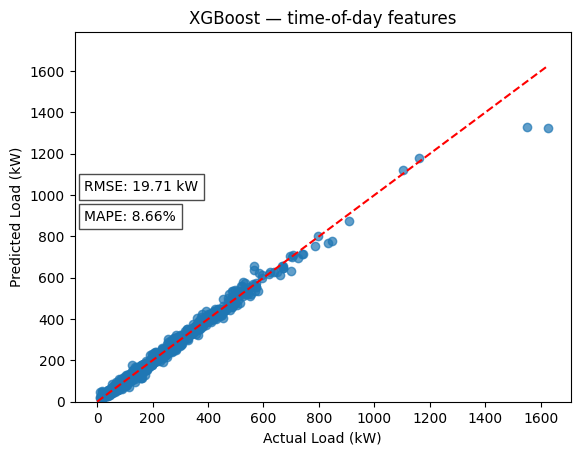

In [47]:
TARGET_COL = 'HP_Peak'

xgb_time_model, xgb_time_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(X, y),
    X_train       = X_train_time,
    y_train       = y_train_time[TARGET_COL],
    model_path    = 'models/xgb_time_model.pkl',
    hyperparams_path = 'models/xgb_time_hyperparams.pkl',
    retrain       = retrain_xgb_time,
)

xgb_pred_time = clip_non_negative(xgb_time_model.predict(X_test_time))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], xgb_pred_time,
    title='XGBoost — time-of-day features')
plt.show()


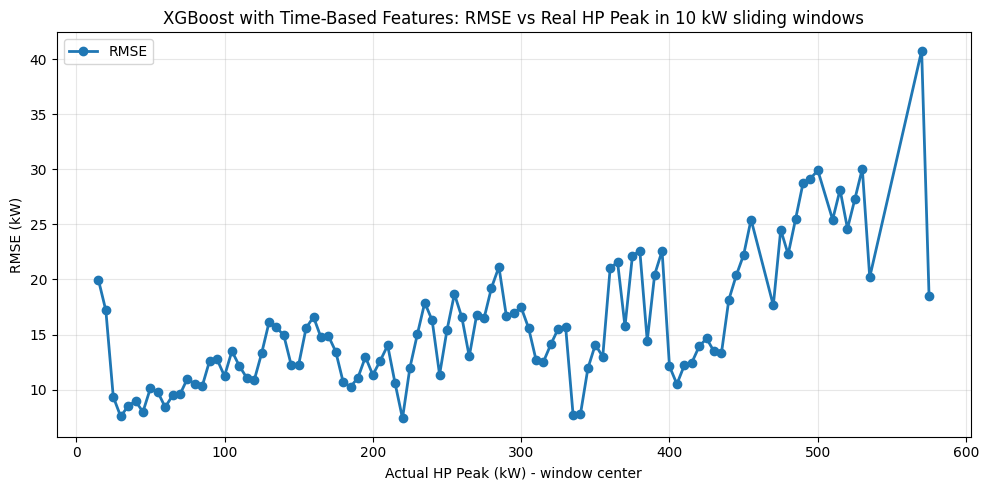

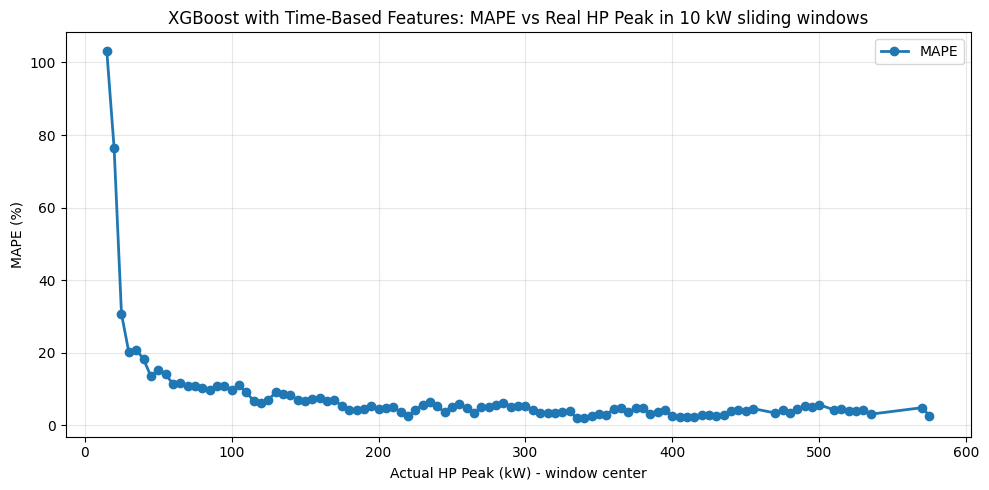

In [48]:
# Actual HP peak values from the test set
y_true = y_test_time['HP_Peak'].to_numpy()

# Predictions from the existing XGBoost model (cell 74)
y_pred = np.asarray(xgb_pred_time).reshape(-1)

# RMSE in rolling/sliding windows of 10 kW on the actual HP values
window_kW = 10.0
step_kW = 5.0  # 50% overlap between consecutive windows

min_val = np.floor(y_true.min() / window_kW) * window_kW
max_val = np.ceil(y_true.max() / window_kW) * window_kW

centers = np.arange(min_val + window_kW / 2, max_val, step_kW)
rmse_vals = []
counts = []

for c in centers:
    mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2)
    n = int(mask.sum())
    counts.append(n)

    if n < 5:
        rmse_vals.append(np.nan)
    else:
        err = y_true[mask] - y_pred[mask]
        rmse_vals.append(np.sqrt(np.mean(err**2)))

centers = np.asarray(centers)
rmse_vals = np.asarray(rmse_vals)
counts = np.asarray(counts)

nonzero_mask = y_true != 0
mape_nonzero = mean_absolute_percentage_error(y_true[nonzero_mask], y_pred[nonzero_mask]) * 100

plt.figure(figsize=(10, 5))
valid = np.isfinite(rmse_vals)
plt.plot(centers[valid], rmse_vals[valid], marker='o', linewidth=2, label='RMSE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('RMSE (kW)')
plt.title(f'XGBoost with Time-Based Features: RMSE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
mape_vals = []

for c in centers:
    window_mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2) & (y_true != 0)
    if int(window_mask.sum()) < 5:
        mape_vals.append(np.nan)
    else:
        err_pct = np.abs((y_true[window_mask] - y_pred[window_mask]) / y_true[window_mask]) * 100
        mape_vals.append(np.mean(err_pct))

mape_vals = np.asarray(mape_vals)

plt.figure(figsize=(10, 5))
valid_mape = np.isfinite(mape_vals)
plt.plot(centers[valid_mape], mape_vals[valid_mape], marker='o', linewidth=2, label='MAPE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('MAPE (%)')
plt.title('XGBoost with Time-Based Features: MAPE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


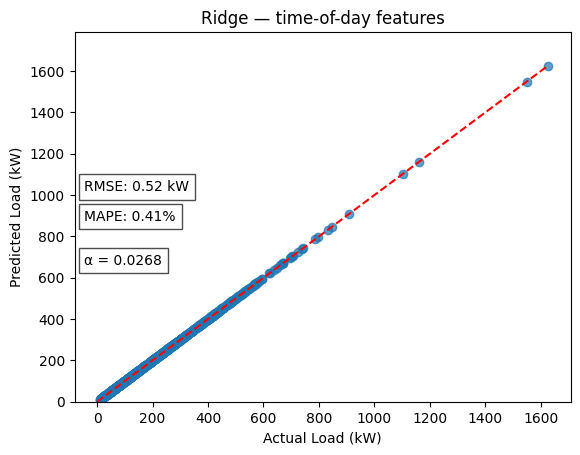

In [49]:
ridge_time_model, _ = load_or_train_model(
    model_factory = lambda X, y: (
        (lambda m: (m.fit(X, y), m)[1])(RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
        {'alpha': None}   # placeholder; alpha recovered from model below
    ),
    X_train       = X_train_time,
    y_train       = y_train_time[TARGET_COL],
    model_path    = 'models/ridge_time_model.pkl',
    hyperparams_path = None,
    retrain       = retrain_ridge_time,
)

# If freshly trained, the factory lambda returns (fitted_model, placeholder_dict).
# load_or_train_model unpacks correctly either way.
if isinstance(ridge_time_model, tuple):
    ridge_time_model = ridge_time_model[0]

ridge_pred_time = clip_non_negative(ridge_time_model.predict(X_test_time))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], ridge_pred_time,
    title='Ridge — time-of-day features')
ax.text(0.02, 0.4, f'α = {ridge_time_model.alpha_:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


## Time-Based + Piecewise Linear Coefficients

In [50]:
substations_time_hockey_train_df = substations_time_df_train.join(piece_lin_coeff_df, how='left')
substations_time_hockey_test_df = substations_time_df_test.join(piece_lin_coeff_df, how='left')

In [51]:
X_train_time_hockey = substations_time_hockey_train_df.drop(columns=['HP_Peak'])
y_train_time_hockey = substations_time_hockey_train_df[['HP_Peak']]

X_test_time_hockey = substations_time_hockey_test_df.drop(columns=['HP_Peak'])
y_test_time_hockey = substations_time_hockey_test_df[['HP_Peak']]


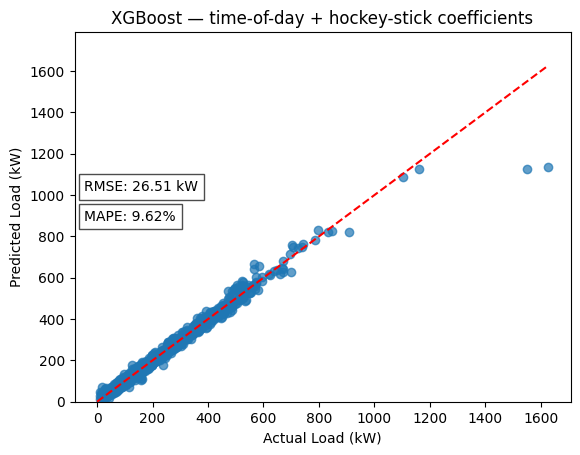

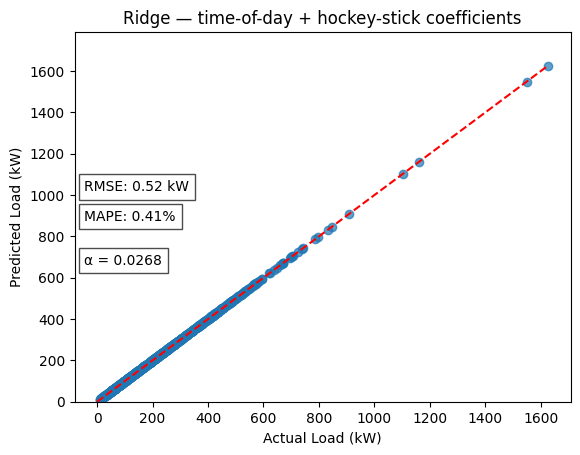

In [52]:
xgb_time_hockey_model, xgb_time_hockey_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(X, y),
    X_train       = X_train_time_hockey,
    y_train       = y_train_time_hockey[TARGET_COL],
    model_path    = 'models/xgb_time_hockey_model.pkl',
    hyperparams_path = 'models/xgb_time_hockey_hyperparams.pkl',
    retrain       = retrain_xgb_time_hockey,
)

xgb_pred_time_hockey = clip_non_negative(xgb_time_hockey_model.predict(X_test_time_hockey))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time_hockey[TARGET_COL], xgb_pred_time_hockey,
    title='XGBoost — time-of-day + hockey-stick coefficients')
plt.show()

ridge_time_hockey_model, _ = load_or_train_model(
    model_factory = lambda X, y: (
        (lambda m: (m.fit(X, y), m)[1])(RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
        {}
    ),
    X_train       = X_train_time_hockey,
    y_train       = y_train_time_hockey[TARGET_COL],
    model_path    = 'models/ridge_time_hockey_model.pkl',
    hyperparams_path = None,
    retrain       = retrain_ridge_time_hockey,
)
if isinstance(ridge_time_hockey_model, tuple):
    ridge_time_hockey_model = ridge_time_hockey_model[0]

ridge_pred_time_hockey = clip_non_negative(ridge_time_hockey_model.predict(X_test_time_hockey))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time_hockey[TARGET_COL], ridge_pred_time_hockey,
    title='Ridge — time-of-day + hockey-stick coefficients')
ax.text(0.02, 0.4, f'α = {ridge_time_hockey_model.alpha_:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


## HDD Bins

In [53]:
# ============================================================
# Helper functions
# ============================================================

def assign_time_window(ts):
    """
    4 broad time windows:
      night   = 00:00-05:59
      morning = 06:00-09:59
      day     = 10:00-15:59
      evening = 16:00-23:59
    """
    h = ts.hour
    if 0 <= h < 6:
        return "night"
    elif 6 <= h < 10:
        return "morning"
    elif 10 <= h < 16:
        return "day"
    else:
        return "evening"


def assign_hdd_bin(severity, mild_thresh, cold_thresh):
    """
    Daily severity bins:
      warm    : severity == 0
      mild    : 0 < severity <= mild_thresh
      cold    : mild_thresh < severity <= cold_thresh
      extreme : severity > cold_thresh
    """
    if pd.isna(severity):
        return np.nan
    if severity <= 0:
        return "warm"
    elif severity <= mild_thresh:
        return "mild"
    elif severity <= cold_thresh:
        return "cold"
    else:
        return "extreme"


def safe_std(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1)


def safe_skew(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan
    return x.skew()


def safe_kurtosis(x):
    x = pd.Series(x).dropna()
    if len(x) < 4:
        return np.nan
    return x.kurt()


def safe_quantile(x, q):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(q)


def safe_cov(x, y):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan
    return np.cov(x, y, ddof=1)[0, 1]


def safe_corr(x, y):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan
    if x.std(ddof=1) == 0 or y.std(ddof=1) == 0:
        return np.nan
    return x.corr(y)


def add_distribution_features(feature_dict, prefix, values,
                              include_minmax=True,
                              include_shape=True,
                              include_quantiles=True):
    """
    Add statistical features for a vector of load values.
    """
    s = pd.Series(values).dropna()

    feature_dict[f"{prefix}_Mean"] = s.mean() if len(s) > 0 else np.nan
    feature_dict[f"{prefix}_Std"] = safe_std(s)

    if include_minmax:
        feature_dict[f"{prefix}_Min"] = s.min() if len(s) > 0 else np.nan
        feature_dict[f"{prefix}_Max"] = s.max() if len(s) > 0 else np.nan
        feature_dict[f"{prefix}_Max-Min"] = (s.max() - s.min()) if len(s) > 0 else np.nan

    if include_shape:
        feature_dict[f"{prefix}_Skew"] = safe_skew(s)
        feature_dict[f"{prefix}_Kurtosis"] = safe_kurtosis(s)

    if include_quantiles:
        feature_dict[f"{prefix}_Q50"] = safe_quantile(s, 0.50)
        feature_dict[f"{prefix}_Q95"] = safe_quantile(s, 0.95)

    feature_dict[f"{prefix}_N_obs"] = len(s)


# ============================================================
# Core function: one entity / one feeder / one substation
# ============================================================

def extract_windowed_hdd_features_from_series(
    load_series,
    temp_series,
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
    return_aligned=False,
):
    """
    Extract windowed HDD-binned features from one load series and one temperature series.

    Parameters
    ----------
    load_series : pd.Series
        Load time series with DatetimeIndex.
    temp_series : pd.Series
        Temperature time series with DatetimeIndex.
    resolution : int
        Resampling resolution in minutes.
    T_base : float
        Base temperature for HDH calculation.
    mild_thresh : float
        Daily HDH severity threshold for mild bin.
    cold_thresh : float
        Daily HDH severity threshold for cold bin.
    weekday_only : bool
        Whether to keep only weekdays.
    window_order : list
        Time windows to use.
    bin_order : list
        HDD bins to use.
    compare_pairs : list of tuple
        Bin pairs for comparative features.
    stats_for_comparison : list
        Which stats to compare across bins.
    epsilon : float
        Small number for ratio denominators.
    include_shape : bool
        Include skew / kurtosis.
    include_minmax : bool
        Include min / max / range.
    include_quantiles : bool
        Include Q50 / Q95.
    include_n_days : bool
        Include N_days per window-bin.
    include_corr_features : bool
        Include correlation/covariance with Temperature and HDH.
    include_climate_context : bool
        Include overall daily severity summary stats.
    normalize_by_peak : bool
        Add peak-normalized magnitude features.
    return_aligned : bool
        If True, also return the aligned timestamp-level dataframe.

    Returns
    -------
    feat : dict
        Feature dictionary for one entity.
    aligned : pd.DataFrame (optional)
        Intermediate aligned dataframe.
    """

    if window_order is None:
        window_order = ["night", "morning", "day", "evening"]

    if bin_order is None:
        bin_order = ["warm", "mild", "cold", "extreme"]

    if compare_pairs is None:
        compare_pairs = [
            ("mild", "warm"),
            ("cold", "warm"),
            ("extreme", "warm"),
            ("extreme", "cold"),
        ]

    if stats_for_comparison is None:
        stats_for_comparison = ["Mean", "Std", "Q50", "Q95", "Max"]

    # --------------------------------------------------------
    # 1) Basic checks
    # --------------------------------------------------------
    if not isinstance(load_series.index, pd.DatetimeIndex):
        raise ValueError("load_series must have a DatetimeIndex")
    if not isinstance(temp_series.index, pd.DatetimeIndex):
        raise ValueError("temp_series must have a DatetimeIndex")

    # --------------------------------------------------------
    # 2) Resample and align
    # --------------------------------------------------------
    load_series = load_series.resample(f"{resolution}min").mean().ffill()
    temp_series = temp_series.resample(f"{resolution}min").mean().ffill()

    if weekday_only:
        load_series = load_series[load_series.index.weekday < 5]
        temp_series = temp_series[temp_series.index.weekday < 5]

    aligned = pd.concat([load_series, temp_series], axis=1, join="inner")
    aligned.columns = ["Total_Load", "Temperature"]
    aligned = aligned.dropna()

    if aligned.empty:
        return ({}, aligned) if return_aligned else {}

    # --------------------------------------------------------
    # 3) Time features + HDH
    # --------------------------------------------------------
    aligned["Date"] = aligned.index.date
    aligned["Window"] = [assign_time_window(ts) for ts in aligned.index]

    aligned["HDH"] = np.maximum(T_base - aligned["Temperature"], 0.0)
    aligned["HDH_qh"] = aligned["HDH"] * (resolution / 60.0)

    daily_severity = aligned.groupby("Date")["HDH_qh"].sum().rename("Daily_HDH_Severity")
    aligned = aligned.join(daily_severity, on="Date")

    aligned["HDD_Bin"] = aligned["Daily_HDH_Severity"].apply(
        lambda x: assign_hdd_bin(x, mild_thresh=mild_thresh, cold_thresh=cold_thresh)
    )

    # --------------------------------------------------------
    # 4) Feature extraction
    # --------------------------------------------------------
    feat = {}

    if include_climate_context:
        feat["Feature Daily_HDH_Severity_Mean"] = daily_severity.mean()
        feat["Feature Daily_HDH_Severity_Std"] = daily_severity.std(ddof=1)
        feat["Feature Daily_HDH_Severity_Max"] = daily_severity.max()
        feat["Feature N_weekdays"] = aligned["Date"].nunique()

    # Per window × HDD bin features
    for window in window_order:
        for hdd_bin in bin_order:
            mask = (aligned["Window"] == window) & (aligned["HDD_Bin"] == hdd_bin)

            load_vals = aligned.loc[mask, "Total_Load"]
            temp_vals = aligned.loc[mask, "Temperature"]
            hdh_vals = aligned.loc[mask, "HDH"]
            n_days = aligned.loc[mask, "Date"].nunique()

            prefix = f"Feature {window}_{hdd_bin}"

            add_distribution_features(
                feat,
                prefix,
                load_vals,
                include_minmax=include_minmax,
                include_shape=include_shape,
                include_quantiles=include_quantiles,
            )

            if include_n_days:
                feat[f"{prefix}_N_days"] = n_days

            if include_corr_features:
                feat[f"{prefix}_Cov_Temp"] = safe_cov(load_vals, temp_vals)
                feat[f"{prefix}_Corr_Temp"] = safe_corr(load_vals, temp_vals)
                feat[f"{prefix}_Cov_HDH"] = safe_cov(load_vals, hdh_vals)
                feat[f"{prefix}_Corr_HDH"] = safe_corr(load_vals, hdh_vals)

    # --------------------------------------------------------
    # 5) Comparative features across bins (within each window)
    # --------------------------------------------------------
    for window in window_order:
        for high_bin, low_bin in compare_pairs:
            for stat in stats_for_comparison:
                high_key = f"Feature {window}_{high_bin}_{stat}"
                low_key = f"Feature {window}_{low_bin}_{stat}"

                high_val = feat.get(high_key, np.nan)
                low_val = feat.get(low_key, np.nan)

                feat[f"Feature {window}_delta_{stat}_{high_bin}_{low_bin}"] = (
                    high_val - low_val
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

                feat[f"Feature {window}_ratio_{stat}_{high_bin}_{low_bin}"] = (
                    high_val / (low_val + epsilon)
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

                feat[f"Feature {window}_normdelta_{stat}_{high_bin}_{low_bin}"] = (
                    (high_val - low_val) / (low_val + epsilon)
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

    # --------------------------------------------------------
    # 6) Optional magnitude normalization by peak load
    # --------------------------------------------------------
    if normalize_by_peak:
        peak_load = aligned["Total_Load"].max()
        magnitude_keys = ["Mean", "Std", "Min", "Max", "Max-Min", "Q50", "Q95"]

        for col in list(feat.keys()):
            if any(col.endswith(f"_{k}") for k in magnitude_keys):
                feat[f"{col}_norm_peak"] = feat[col] / peak_load if pd.notna(peak_load) and peak_load != 0 else np.nan

    return (feat, aligned) if return_aligned else feat


# ============================================================
# Wrapper 1: HEAPO-style dataframe with one series per row
# ============================================================

def extract_windowed_hdd_features_from_entity_dataframe(
    entity_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
    show_progress=True,
):
    """
    Apply the feature extraction to a dataframe where each row contains:
      - a load series
      - a temperature series

    Example: HEAPO substations_df
    """

    feat_dict = {}

    iterator = trange(len(entity_df), desc="Extracting windowed HDD-binned features") if show_progress else range(len(entity_df))

    for i in iterator:
        load_series = entity_df.iloc[i][load_col]
        temp_series = entity_df.iloc[i][temp_col]

        feat = extract_windowed_hdd_features_from_series(
            load_series=load_series,
            temp_series=temp_series,
            resolution=resolution,
            T_base=T_base,
            mild_thresh=mild_thresh,
            cold_thresh=cold_thresh,
            weekday_only=weekday_only,
            window_order=window_order,
            bin_order=bin_order,
            compare_pairs=compare_pairs,
            stats_for_comparison=stats_for_comparison,
            epsilon=epsilon,
            include_shape=include_shape,
            include_minmax=include_minmax,
            include_quantiles=include_quantiles,
            include_n_days=include_n_days,
            include_corr_features=include_corr_features,
            include_climate_context=include_climate_context,
            normalize_by_peak=normalize_by_peak,
            return_aligned=False,
        )

        feat_dict[i] = feat

    return pd.DataFrame.from_dict(feat_dict, orient="index")


# ============================================================
# Wrapper 2: generic dictionary/list interface
# ============================================================

def extract_windowed_hdd_features_from_mapping(
    data_mapping,
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
):
    """
    Apply the feature extraction to a mapping like:

    data_mapping = {
        "entity_1": {"load": load_series_1, "temp": temp_series_1},
        "entity_2": {"load": load_series_2, "temp": temp_series_2},
    }
    """

    feat_dict = {}

    for key, value in data_mapping.items():
        feat_dict[key] = extract_windowed_hdd_features_from_series(
            load_series=value["load"],
            temp_series=value["temp"],
            resolution=resolution,
            T_base=T_base,
            mild_thresh=mild_thresh,
            cold_thresh=cold_thresh,
            weekday_only=weekday_only,
            window_order=window_order,
            bin_order=bin_order,
            compare_pairs=compare_pairs,
            stats_for_comparison=stats_for_comparison,
            epsilon=epsilon,
            include_shape=include_shape,
            include_minmax=include_minmax,
            include_quantiles=include_quantiles,
            include_n_days=include_n_days,
            include_corr_features=include_corr_features,
            include_climate_context=include_climate_context,
            normalize_by_peak=normalize_by_peak,
            return_aligned=False,
        )

    return pd.DataFrame.from_dict(feat_dict, orient="index")

In [54]:
# Shared boolean arguments for all windowed HDD feature extractions
windowed_hdd_feature_kwargs = dict(
    weekday_only=True,
    include_shape=False,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=False,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=True,
)

def build_windowed_hdd_kwargs(**overrides):
    kwargs = dict(windowed_hdd_feature_kwargs)
    kwargs.update(overrides)
    return kwargs

In [156]:
substations_windowed_hdd_df = extract_windowed_hdd_features_from_entity_dataframe(
    entity_df=substations_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs(),
)


Extracting windowed HDD-binned features: 100%|██████████| 2000/2000 [04:22<00:00,  7.61it/s]


In [157]:
train_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_train.index)
train_idx = train_idx.intersection(y_train_time_hockey.index)

test_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_test.index)
test_idx = test_idx.intersection(y_test_time_hockey.index)

X_train_windowed_hdd = substations_windowed_hdd_df.loc[train_idx].copy()
y_train_windowed_hdd = y_train_time_hockey.loc[train_idx, 'HP_Peak'].copy()

X_test_windowed_hdd = substations_windowed_hdd_df.loc[test_idx].copy()
y_test_windowed_hdd = y_test_time_hockey.loc[test_idx, 'HP_Peak'].copy()

In [158]:
feature_presets = [
    "mean_q95_only",
    "comparative_mean_q95",
    "core",
    "comparative_only",
    "no_shape_no_corr",
    "per_bin_only",
    "all",
]

In [159]:
def get_feature_columns(X, preset):
    cols = list(X.columns)

    if preset == "all":
        return cols

    if preset == "core":
        return [
            c for c in cols
            if (
                c.endswith("_Mean")
                or c.endswith("_Std")
                or c.endswith("_Q50")
                or c.endswith("_Q95")
                or "delta_Mean" in c
                or "delta_Q95" in c
                or "ratio_Mean" in c
                or "ratio_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "mean_q95_only":
        return [
            c for c in cols
            if (
                c.endswith("_Mean")
                or c.endswith("_Q95")
                or "delta_Mean" in c
                or "delta_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "comparative_only":
        return [
            c for c in cols
            if (
                "delta_" in c
                or "ratio_" in c
                or "normdelta_" in c
            )
        ]

    if preset == "comparative_mean_q95":
        return [
            c for c in cols
            if (
                "delta_Mean" in c
                or "delta_Q95" in c
                or "ratio_Mean" in c
                or "ratio_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "per_bin_only":
        return [
            c for c in cols
            if not (
                "delta_" in c
                or "ratio_" in c
                or "normdelta_" in c
            )
        ]

    if preset == "no_shape_no_corr":
        return [
            c for c in cols
            if (
                "Skew" not in c
                and "Kurtosis" not in c
                and "Corr" not in c
                and "Cov" not in c
            )
        ]

    raise ValueError(f"Unknown preset: {preset}")


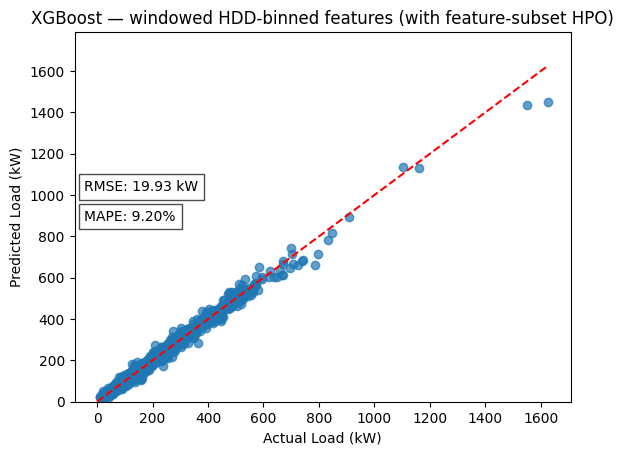

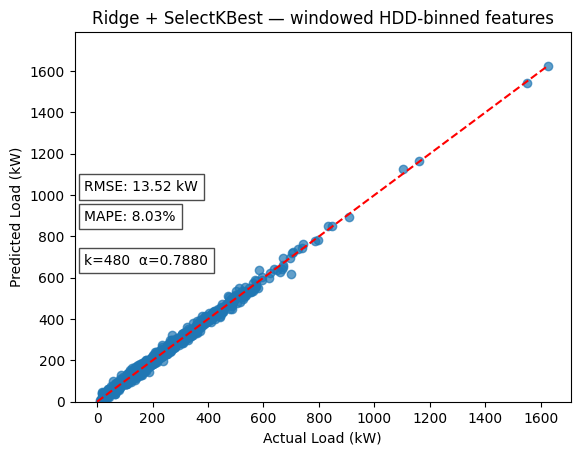

In [160]:
# Build all feature-preset column lists once, then pass them into both models
# so that feature-subset selection becomes part of their hyperparameter search.
hdd_feature_presets = feature_presets  # defined in cell 100
hdd_feature_col_lists = [
    get_feature_columns(X_train_windowed_hdd, p)
    for p in hdd_feature_presets
]
# Drop empty presets
hdd_feature_col_lists = [c for c in hdd_feature_col_lists if len(c) > 0]

# ── XGBoost with feature-subset HPO ──────────────────────────────────────
xgb_windowed_hdd_model, xgb_windowed_hdd_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(
        X, y, feature_columns=hdd_feature_col_lists),
    X_train       = X_train_windowed_hdd,
    y_train       = y_train_windowed_hdd,
    model_path    = 'models/xgb_windowed_hdd_model.pkl',
    hyperparams_path = 'models/xgb_windowed_hdd_hyperparams.pkl',
    retrain       = retrain_xgb_windowed_hdd,
)

# When loaded from disk the model was already fit on the best feature subset;
# recover which columns it expects from the saved metadata.
_xgb_hdd_best_cols = xgb_windowed_hdd_hyperparams.get(
    'best_feature_cols', X_train_windowed_hdd.columns.tolist())
xgb_pred_windowed_hdd = clip_non_negative(
    xgb_windowed_hdd_model.predict(X_test_windowed_hdd[_xgb_hdd_best_cols]))

fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_windowed_hdd, xgb_pred_windowed_hdd,
    title='XGBoost — windowed HDD-binned features (with feature-subset HPO)')
plt.show()

# ── Ridge with SelectKBest feature selection (k tuned via CV) ────────────
ridge_windowed_hdd_model, ridge_windowed_hdd_params = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_ridge(X, y),
    X_train       = X_train_windowed_hdd,
    y_train       = y_train_windowed_hdd,
    model_path    = 'models/ridge_windowed_hdd_model.pkl',
    hyperparams_path = 'models/ridge_windowed_hdd_hyperparams.pkl',
    retrain       = retrain_ridge_windowed_hdd,
)

ridge_pred_windowed_hdd = clip_non_negative(
    ridge_windowed_hdd_model.predict(X_test_windowed_hdd))

fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_windowed_hdd, ridge_pred_windowed_hdd,
    title='Ridge + SelectKBest — windowed HDD-binned features')
best_k = ridge_windowed_hdd_params.get('selector__k', '?')
best_alpha = ridge_windowed_hdd_model.named_steps['ridge'].alpha_
ax.text(0.02, 0.4, f'k={best_k}  α={best_alpha:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


In [161]:
# Ridge windowed-HDD model is now in cell 70.


## Partial Least Squares (PLS)

### PLS on raw load time series

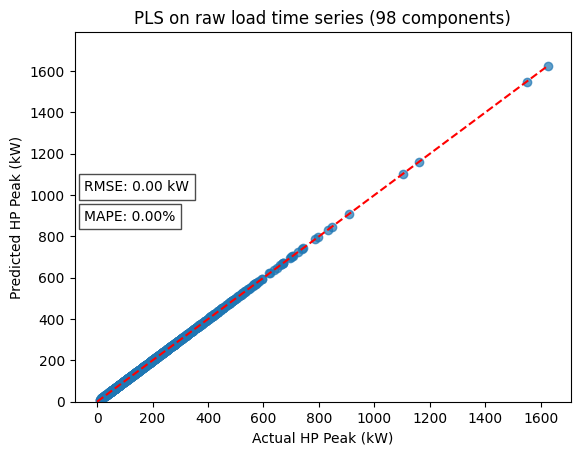

In [162]:
# Stack each substation's full load time series as a flat feature row.
pls_ts_train = np.vstack([substations_df_train.iloc[i]['Total_Load'].values
                           for i in range(len(substations_df_train))])
pls_ts_test  = np.vstack([substations_df_test.iloc[i]['Total_Load'].values
                           for i in range(len(substations_df_test))])

# Fill any NaNs from ffill
pls_ts_train = pd.DataFrame(pls_ts_train).ffill(axis=1).values
pls_ts_test  = pd.DataFrame(pls_ts_test).ffill(axis=1).values

y_train_pls = substations_df_train['HP_Peak'].values
y_test_pls  = substations_df_test['HP_Peak'].values

def _make_pls_pipeline(n_comp):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pls',     PLSRegression(n_components=n_comp)),
    ])

def tune_and_train_pls(X_train, y_train, n_comp_range=None):
    """Select n_components via 5-fold CV on training data, then refit."""
    max_comp = min(X_train.shape[0], X_train.shape[1], 100)
    if n_comp_range is None:
        n_comp_range = list(range(2, max_comp, max(1, max_comp // 30)))

    param_grid = {'pls__n_components': n_comp_range}
    cv_search  = GridSearchCV(_make_pls_pipeline(1), param_grid,
                              scoring='neg_root_mean_squared_error',
                              cv=5, n_jobs=-1)
    cv_search.fit(X_train, y_train)
    best_n = cv_search.best_params_['pls__n_components']
    print(f"Best n_components (CV): {best_n}  |  "
          f"CV RMSE: {-cv_search.best_score_:.2f} kW")
    return cv_search.best_estimator_, {'n_components': best_n,
                                        'cv_results': cv_search.cv_results_}


pls_ts_model, pls_ts_meta = load_or_train_model(
    model_factory    = lambda X, y: tune_and_train_pls(X, y),
    X_train          = pls_ts_train,
    y_train          = y_train_pls,
    model_path       = 'models/pls_time_series_model.pkl',
    hyperparams_path = 'models/pls_time_series_meta.pkl',
    retrain          = retrain_pls_time_series,
)

pls_ts_pred = clip_non_negative(pls_ts_model.predict(pls_ts_test).ravel())
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_pls, pls_ts_pred,
    title=f'PLS on raw load time series ({pls_ts_meta["n_components"]} components)',
    xlabel='Actual HP Peak (kW)', ylabel='Predicted HP Peak (kW)')
plt.show()


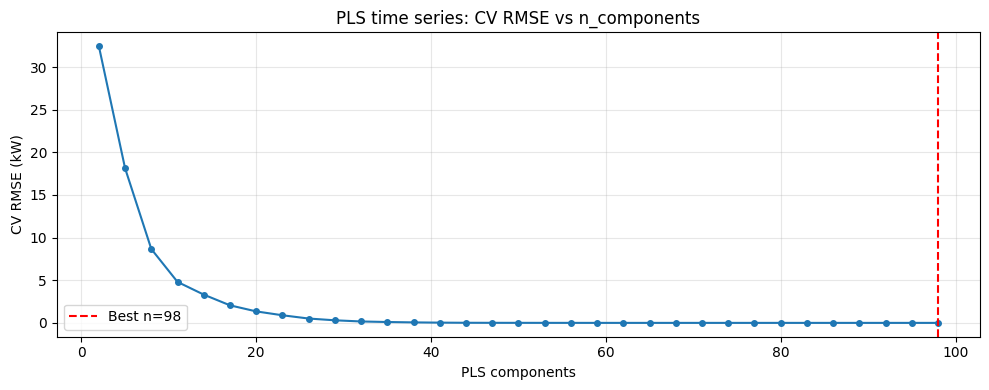

In [163]:
cv_res = pls_ts_meta.get('cv_results', {})
if cv_res:
    n_vals  = [p['pls__n_components'] for p in cv_res['params']]
    rmse_cv = [-s for s in cv_res['mean_test_score']]
    plt.figure(figsize=(10, 4))
    plt.plot(n_vals, rmse_cv, marker='o', ms=4)
    plt.axvline(pls_ts_meta['n_components'], color='red', ls='--',
                label=f"Best n={pls_ts_meta['n_components']}")
    plt.xlabel('PLS components')
    plt.ylabel('CV RMSE (kW)')
    plt.title('PLS time series: CV RMSE vs n_components')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [164]:
# XGBoost PCA sweep removed — see PLS sections above for dimensionality reduction.


In [165]:
# PCA XGBoost refit cell removed — see PLS sections above.


In [166]:
# PCA XGBoost diagnostic plot removed — see PLS sections above.


### PLS on time-of-day feature matrix

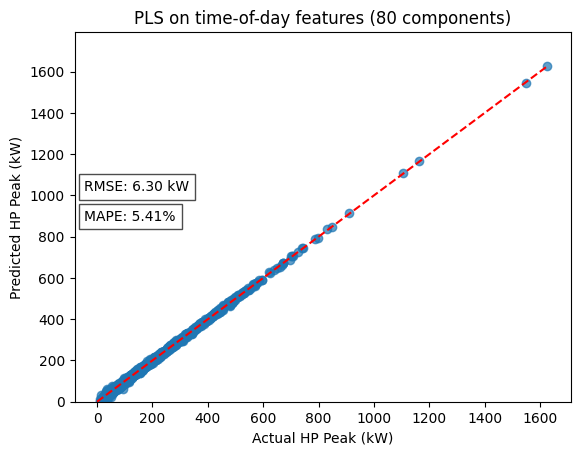

In [167]:
pls_feat_model, pls_feat_meta = load_or_train_model(
    model_factory    = lambda X, y: tune_and_train_pls(X, y),
    X_train          = X_train_time.values,
    y_train          = y_train_time[TARGET_COL].values,
    model_path       = 'models/pls_features_model.pkl',
    hyperparams_path = 'models/pls_features_meta.pkl',
    retrain          = retrain_pls_features,
)

pls_feat_pred = clip_non_negative(pls_feat_model.predict(X_test_time.values).ravel())
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], pls_feat_pred,
    title=f'PLS on time-of-day features ({pls_feat_meta["n_components"]} components)',
    xlabel='Actual HP Peak (kW)', ylabel='Predicted HP Peak (kW)')
plt.show()


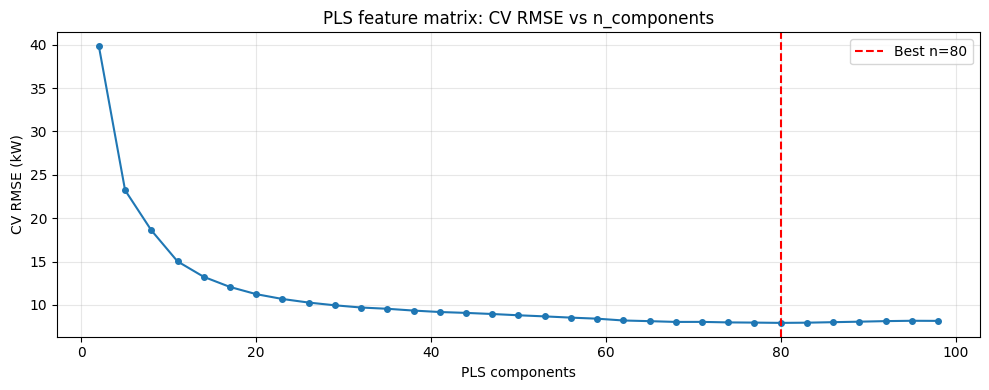

In [168]:
cv_res_feat = pls_feat_meta.get('cv_results', {})
if cv_res_feat:
    n_vals_f  = [p['pls__n_components'] for p in cv_res_feat['params']]
    rmse_cv_f = [-s for s in cv_res_feat['mean_test_score']]
    plt.figure(figsize=(10, 4))
    plt.plot(n_vals_f, rmse_cv_f, marker='o', ms=4)
    plt.axvline(pls_feat_meta['n_components'], color='red', ls='--',
                label=f"Best n={pls_feat_meta['n_components']}")
    plt.xlabel('PLS components')
    plt.ylabel('CV RMSE (kW)')
    plt.title('PLS feature matrix: CV RMSE vs n_components')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## WPUQ Dataset

In [169]:
def detect_outliers_wpuq_15min(
    
s,
    lower=0,
    upper=10000,          # W
    days_window=14,       # same quarter-hour across ±14 days
    n_sigma=2.8,          # aggressive
    max_replace_run=4,    # up to 1 hour
    max_interp_run=8,     # up to 2 hours
    passes=2
):
    """
    Aggressive outlier removal for 15-minute WPuQ heat-pump series.

    Parameters
    ----------
    s : pd.Series
        15-minute time series with DateTimeIndex.
    lower, upper : float
        Physical plausibility bounds.
    days_window : int
        Number of days on each side for same-time-of-day seasonal baseline.
    n_sigma : float
        Hampel/MAD threshold on residuals.
    max_replace_run : int
        Consecutive flagged bins replaced by baseline.
    max_interp_run : int
        Consecutive flagged bins interpolated linearly.
    passes : int
        Number of cleaning passes.

    Returns
    -------
    cleaned : pd.Series
    outlier_mask : pd.Series[bool]
    baseline : pd.Series
    """
    s = s.copy().astype(float)
    steps_per_day = 96
    global_mask = pd.Series(False, index=s.index)

    def seasonal_baseline(x):
        base = pd.Series(index=x.index, dtype=float)
        vals = x.values
        n = len(x)

        for i in range(n):
            refs = []
            for d in range(1, days_window + 1):
                for sign in (-1, 1):
                    j = i + sign * d * steps_per_day
                    if 0 <= j < n and not np.isnan(vals[j]):
                        refs.append(vals[j])
            if refs:
                base.iloc[i] = np.median(refs)
            else:
                base.iloc[i] = np.nan

        # fallback near edges
        fallback = x.rolling(steps_per_day, center=True, min_periods=1).median()
        return base.fillna(fallback)

    cleaned = s.copy()

    for _ in range(passes):
        base = seasonal_baseline(cleaned)

        # physical outliers
        mask_phys = (cleaned < lower) | (cleaned > upper)

        # residual outliers
        resid = cleaned - base
        med_r = np.nanmedian(resid)
        mad_r = np.nanmedian(np.abs(resid - med_r))
        if not np.isfinite(mad_r) or mad_r == 0:
            mad_r = 1.0

        mask_resid = np.abs(resid - med_r) > (n_sigma * 1.4826 * mad_r)

        # gradient outliers
        dx = cleaned.diff()
        med_dx = np.nanmedian(dx)
        mad_dx = np.nanmedian(np.abs(dx - med_dx))
        if not np.isfinite(mad_dx) or mad_dx == 0:
            mad_dx = 1.0

        jump_prev = np.abs(cleaned - cleaned.shift(1)) > (3 * 1.4826 * mad_dx)
        jump_next = np.abs(cleaned - cleaned.shift(-1)) > (3 * 1.4826 * mad_dx)
        mask_grad = mask_resid & (jump_prev | jump_next)

        mask = (mask_phys | mask_resid | mask_grad).fillna(False)
        global_mask |= mask

        # handle runs
        run_id = (mask != mask.shift()).cumsum()
        run_len = mask.groupby(run_id).transform("size")

        replace_mask = mask & (run_len <= max_replace_run)
        interp_mask = mask & (run_len > max_replace_run) & (run_len <= max_interp_run)

        cleaned[replace_mask] = base[replace_mask]
        cleaned[interp_mask] = np.nan
        cleaned = cleaned.interpolate(limit=max_interp_run, limit_direction="both")

    baseline = seasonal_baseline(cleaned)
    return cleaned, global_mask, baseline


In [170]:
wpuq_data = h5py.File('data\\2019_data_15min.hdf5', 'r')
wpuq_transf_df = pd.DataFrame(np.array(wpuq_data['MISC']['ES1']['TRANSFORMER']['table'])) 
wpuq_transf_df['index'] = pd.to_datetime(wpuq_transf_df['index'], utc=True, origin='unix', unit='s')
wpuq_transf_df['P_TOT'] = wpuq_transf_df['P_TOT'] / 1000  # Convert W to kW

substation_total = wpuq_transf_df.set_index('index')
substation_total['Date'] = substation_total.index.date
substation_total['Time'] = substation_total.index.time
substation_total = substation_total[['P_TOT', 'Date', 'Time']]

In [171]:
wpuq_weather = h5py.File('data\\2019_weather.hdf5', 'r')
wpuq_weather_df = pd.DataFrame(np.array(wpuq_weather['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']))
wpuq_weather_df['index'] = pd.to_datetime(wpuq_weather_df['index'], utc=True, origin='unix', unit='ns')

wpuq_weather_df = wpuq_weather_df.set_index('index').resample('15min').mean()[:-1]
wpuq_weather_df.index = wpuq_weather_df.index.shift(periods=1, freq='h')
wpuq_weather_df['Date'] = wpuq_weather_df.index.date
wpuq_weather_df['Time'] = wpuq_weather_df.index.time

# wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]  # Keep only weekdays
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index >= pd.Timestamp('2019-01-01 00:00:00', tz='UTC')]
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index <= pd.Timestamp('2019-12-31 23:45:00', tz='UTC')]  # Keep only 2019 data

wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].interpolate(method='time')
wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].ffill().bfill()

In [ ]:
wpuq_hp_data = {}
wpuq_house_data = {}

full_year_no_weekends_wpuq = pd.date_range(start='2019-01-01', end='2019-12-31 23:45:00', freq='15min', tz='UTC')
# full_year_no_weekends_wpuq = full_year_no_weekends_wpuq[full_year_no_weekends_wpuq.weekday < 5]  # filter to weekdays

for building in wpuq_data['NO_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW

# --------------------------------

for building in wpuq_data['WITH_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW


Building: SFH10, Original HP Peak: 13.50 kW, Cleaned HP Peak: 11.08 kW
Building: SFH11, Original HP Peak: 8.41 kW, Cleaned HP Peak: 8.41 kW
Building: SFH12, Original HP Peak: 6.94 kW, Cleaned HP Peak: 6.94 kW
Building: SFH14, Original HP Peak: 11.76 kW, Cleaned HP Peak: 11.54 kW


In [72]:
wpuq_hp_df = pd.DataFrame(wpuq_hp_data).reset_index(drop=True)
wpuq_house_df = pd.DataFrame(wpuq_house_data).reset_index(drop=True)

wpuq_total_hp = wpuq_hp_df.sum(axis=1)
wpuq_total_house = wpuq_house_df.sum(axis=1)

wpuq_total = {}

wpuq_total['Load'] = wpuq_total_hp.values + wpuq_total_house.values
wpuq_total['Date'] = wpuq_weather_df['Date'].values
wpuq_total['Time'] = wpuq_weather_df['Time'].values

wpuq_total_df = pd.DataFrame(wpuq_total, index=wpuq_weather_df.index)

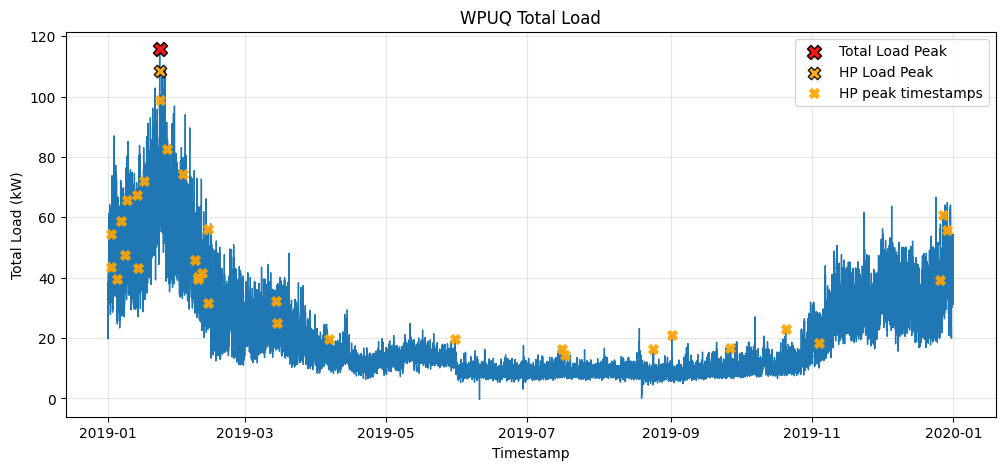

In [73]:
plt.figure(figsize=(12, 5))
plt.plot(wpuq_total_df.index, wpuq_total_df['Load'], lw=1)
plt.xlabel('Timestamp')
plt.ylabel('Total Load (kW)')
plt.title('WPUQ Total Load')

total_peak_ts = wpuq_total_df['Load'].idxmax()
total_peak_val = wpuq_total_df['Load'].max()

plt.scatter(
    total_peak_ts,
    total_peak_val,
    color='red',
    marker='X',
    s=100,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.2,
    zorder=10,
    label='Total Load Peak'
)

hp_peak_ts = wpuq_total_df.index[wpuq_total_hp.idxmax()]
hp_peak_val = wpuq_total_hp.max()

plt.scatter(
    hp_peak_ts,
    hp_peak_val,
    color='orange',
    marker='X',
    s=80,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,
    label='HP Load Peak'
)

hp_peak_times = []
hp_peak_vals = []

for col in wpuq_hp_df.columns:
    s = wpuq_hp_df[col].fillna(0)
    if s.empty:
        continue
    peak_ts = wpuq_total_df.index[s.idxmax()]
    hp_peak_times.append(peak_ts)
    hp_peak_vals.append(wpuq_total_df.at[peak_ts, 'Load'])

if hp_peak_times:
    plt.scatter(
        hp_peak_times,
        hp_peak_vals,
        color='orange',
        marker='X',
        s=50,
        alpha=0.9,
        edgecolors='orange',
        linewidths=0.8,
        zorder=10,
        label='HP peak timestamps'
    )
    plt.legend()
    plt.grid(alpha=0.3)
else:
    print("No HP peak timestamps aligned with total load index.")
plt.show()

In [74]:
wpuq_target = {}
wpuq_target['HP_Average'] = np.mean(wpuq_total_hp)
wpuq_target['HP_Peak'] = np.sum([wpuq_hp_df[hid].max() for hid in wpuq_hp_df.columns])
wpuq_target['HP_Simult_Peak'] = wpuq_total_hp.max()
wpuq_target['HP_Capacity_Factor'] = np.mean(wpuq_total_hp) / np.max(wpuq_total_hp)
wpuq_target['HP_Total_Energy'] = wpuq_total_hp.sum() / 4
wpuq_target['HP_Simult_Factor'] = np.max(wpuq_total_hp) / wpuq_target['HP_Peak']

In [75]:
wpuq_total_no_weekends = wpuq_total_df[wpuq_total_df.index.weekday < 5]
wpuq_weather_no_weekends = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]

dailyLoad = wpuq_total_no_weekends.pivot(index='Date', columns='Time', values='Load').ffill()

dailyWeather = wpuq_weather_no_weekends.pivot(index='Date', columns='Time', values='TEMPERATURE:TOTAL').ffill()

dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

T_base = HEATING_SEASON_THRESH  # must match training (cell 54)

hdh = np.maximum(0, T_base - dailyWeather)

dailyFeatures = {}
dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
dailyFeatures['Std'] = dailyLoad.std(axis=0)
dailyFeatures['Min'] = dailyLoad.min(axis=0)
dailyFeatures['Max'] = dailyLoad.max(axis=0)
dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1] 
                                            for i in range(dailyLoad.shape[1])])
dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic
dailyFeatures['Corr_HDH'] = pearsonr(x=dailyLoad, y=hdh, axis=0).statistic

dailyFeaturesDf = pd.DataFrame(dailyFeatures)

# features = {}
# features['Mean'] = dailyFeaturesDf.mean()
# features['Std'] = dailyFeaturesDf.std()
# features['Min'] = dailyFeaturesDf.min()
# features['Max'] = dailyFeaturesDf.max()
# features['Median'] = dailyFeaturesDf.median()

wpuq_features = {}

for key_main in dailyFeaturesDf.keys():
    for key_sub in dailyFeaturesDf.index:
        wpuq_features[f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

wpuq_featuresDf = pd.DataFrame.from_dict(wpuq_features, orient='index').T

corr_cols = [c for c in wpuq_featuresDf.columns if 'Corr' in c]
other_cols = [c for c in wpuq_featuresDf.columns if c not in corr_cols]

wpuq_featuresDf[corr_cols] = wpuq_featuresDf[corr_cols].apply(lambda col: col.fillna(col.median()))
wpuq_featuresDf[other_cols] = wpuq_featuresDf[other_cols].fillna(0)


# Peak-load-normalized features (same normalization as HEAPO training data).

peak_load = wpuq_total_no_weekends['Load'].max()
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(wpuq_featuresDf.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load



C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_5412\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [76]:
wpuq_features_windowed_hdd = extract_windowed_hdd_features_from_series(
    load_series=wpuq_total_df["Load"],
    temp_series=wpuq_weather_df["TEMPERATURE:TOTAL"],
    resolution=15,
    T_base=HEATING_SEASON_THRESH,  # must match training (cell 68)
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs()
)

wpuq_features_windowed_hddDf = pd.DataFrame([wpuq_features_windowed_hdd], index=["WPUQ"])

In [77]:
x_wpuq, y_wpuq = daily_min_max_heating_season(
    wpuq_weather_df['TEMPERATURE:TOTAL'],
    wpuq_total_df['Load'],
    heating_season_thresh=HEATING_SEASON_THRESH
)

base_load_wpuq, hp_sensitivity_wpuq, T_balance_wpuq, r2_wpuq = fit_hockey_stick(x_wpuq, y_wpuq, T_BALANCE_BOUNDS)

print(f"WPUQ Hockey-Stick Fit: Base Load={base_load_wpuq:.2f} kW, "
      f"HP Sensitivity={hp_sensitivity_wpuq:.3f} kW/°C, "
      f"T_balance={T_balance_wpuq:.2f}°C, R²={r2_wpuq:.3f}")

WPUQ Hockey-Stick Fit: Base Load=0.66 kW, HP Sensitivity=3.991 kW/°C, T_balance=13.61°C, R²=0.507


In [78]:
wpuq_coeff_hourly = {}

wpuq_coeff_hourly[0] = {}

try:
    temp_h = wpuq_weather_df['TEMPERATURE:TOTAL'].resample('h').mean()
    load_h = wpuq_total_df['Load'].resample('h').mean()

    sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

    for group_name, hours in hour_groups.items():
        group_data = sm_data[sm_data.index.hour.isin(hours)]

        x = group_data['Temperature'].values
        y = group_data['Total_Load'].values

        if len(x) < MIN_HEATING_DAYS:
            continue

        try:
            base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
        except Exception:
            continue

        wpuq_coeff_hourly[0][f'{group_name}_BaseLoad'] = base_load
        wpuq_coeff_hourly[0][f'{group_name}_Sensitivity'] = hp_sensitivity
        wpuq_coeff_hourly[0][f'{group_name}_TBalance'] = T_balance
        wpuq_coeff_hourly[0][group_name] = r2

except Exception:
    pass

wpuq_coeff_hourly_df = pd.DataFrame.from_dict(wpuq_coeff_hourly, orient='index')

In [79]:
wpuq_sensitivities = wpuq_coeff_hourly_df[sensitivity_cols]

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


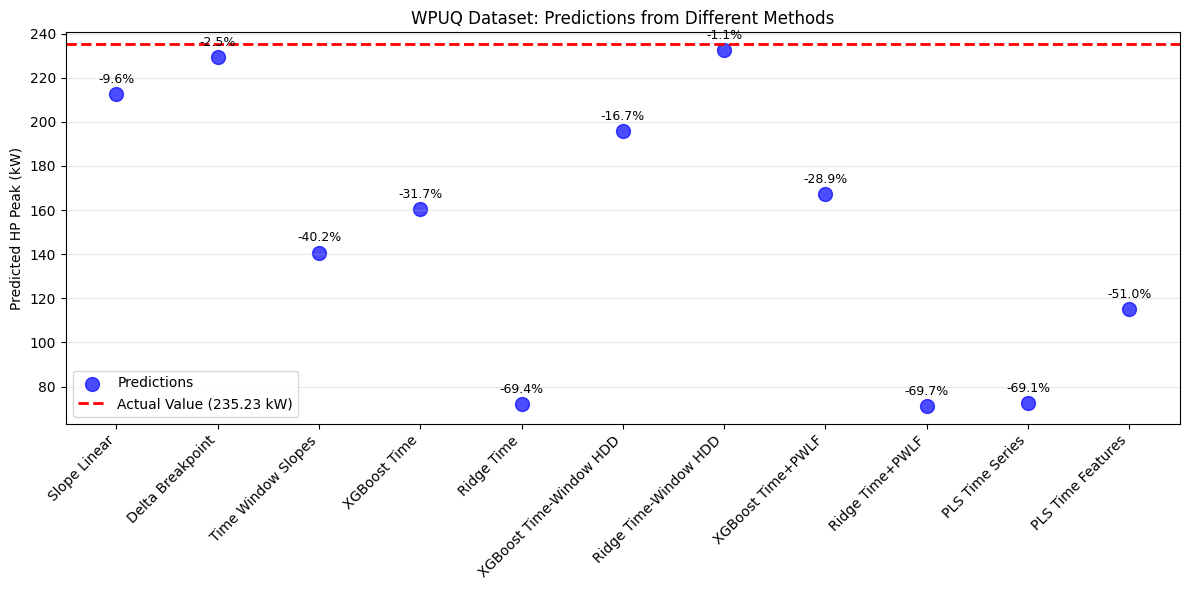

In [80]:
def make_prediction_series(model, features):
    preds = model.predict(features)
    return clip_non_negative(preds)


slope_pred_wpuq = modelLinSlope.predict(np.array([[hp_sensitivity_wpuq]]))
non_sim_delta_pred_wpuq = nonSimDeltaFit.predict(np.array([[hp_sensitivity_wpuq]]))

sens_time_window_pred_wpuq = sensitivity_model.predict(wpuq_sensitivities)

X_wpuq_time = wpuq_featuresDf

if 'xgb_time_model' in globals():
    xgb_time_pred = make_prediction_series(xgb_time_model, X_wpuq_time)

if 'ridge_time_model' in globals():
    ridge_time_pred = make_prediction_series(ridge_time_model, X_wpuq_time)

xgb_pred_windowed_hdd_wpuq = make_prediction_series(xgb_windowed_hdd_model, wpuq_features_windowed_hddDf)
ridge_pred_windowed_hdd_wpuq = make_prediction_series(ridge_windowed_hdd_model, wpuq_features_windowed_hddDf)

X_wpuq_pwlf = X_wpuq_time.join(pd.DataFrame({
    'Base_Load': base_load_wpuq,
    'HP_Sensitivity': hp_sensitivity_wpuq,
    'T_Balance': T_balance_wpuq,
}, index=X_wpuq_time.index))

if 'xgb_time_hockey_model' in globals():
    xgb_time_hockey_pred = make_prediction_series(xgb_time_hockey_model, X_wpuq_pwlf)

if 'ridge_time_hockey_model' in globals():
    ridge_time_hockey_pred = make_prediction_series(ridge_time_hockey_model, X_wpuq_pwlf)

pls_ts_wpuq = wpuq_total_df['Load'].values
pls_pred_wpuq = pls_ts_model.predict(pls_ts_wpuq.reshape(1, -1)).ravel()               

pls_feat_wpuq = X_wpuq_time.values
pls_feat_pred_wpuq = pls_feat_model.predict(pls_feat_wpuq).ravel()

# Create comparison plot of all methods
fig, ax = plt.subplots(figsize=(12, 6))

methods = [
    ('Slope Linear', slope_pred_wpuq[0]),
    ('Delta Breakpoint', non_sim_delta_pred_wpuq[0]),
    ('Time Window Slopes', sens_time_window_pred_wpuq[0]),
    ('XGBoost Time', xgb_time_pred[0]),
    ('Ridge Time', ridge_time_pred[0]),
    ('XGBoost Time-Window HDD', xgb_pred_windowed_hdd_wpuq[0]),
    ('Ridge Time-Window HDD', ridge_pred_windowed_hdd_wpuq[0]),
    ('XGBoost Time+PWLF', xgb_time_hockey_pred[0]),
    ('Ridge Time+PWLF', ridge_time_hockey_pred[0]),
    ('PLS Time Series', pls_pred_wpuq[0]),
    ('PLS Time Features', pls_feat_pred_wpuq[0])
]

x_pos = range(len(methods))
method_names = [method_name for method_name, _ in methods]
predictions = [prediction for _, prediction in methods]

actual = wpuq_target['HP_Peak']
for x, pred in zip(x_pos, predictions):
    pct_err = 100 * (pred - actual) / actual
    ax.annotate(
        f'{pct_err:+.1f}%',
        (x, pred),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

ax.scatter(x_pos, predictions, s=100, alpha=0.7, color='blue', label='Predictions')
ax.axhline(y=wpuq_target['HP_Peak'], color='red', linestyle='--', linewidth=2, label=f'Actual Value ({wpuq_target["HP_Peak"]:.2f} kW)')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.set_ylabel('Predicted HP Peak (kW)')
ax.set_title('WPUQ Dataset: Predictions from Different Methods')
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()
plt.show()


In [81]:
# ------------------------------------------------------------
# Main settings
# ------------------------------------------------------------

target_col = "HP_Peak"

resolution = 15
T_base_ch = 12.0
T_base_de = 15.0
mild_thresh = 10.0
cold_thresh = 25.0

os.makedirs("data", exist_ok=True)

max_feature_kwargs = dict(
    weekday_only=True,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=False,
    include_corr_features=True,
    include_climate_context=False,
    normalize_by_peak=True,
    stats_for_comparison=["Mean", "Std", "Q50", "Q95", "Max"],
)

swiss_feature_path = "data/X_swiss_windowed_hdd_all.pkl"
german_feature_path = "data/X_german_windowed_hdd_all.pkl"

swiss_df = substations_df

german_df = pd.DataFrame.from_dict({'WPUQ': {"Total_Load": wpuq_total_df['Load'], "Temperature": wpuq_weather_df['TEMPERATURE:TOTAL']}}).T

force_recompute_features = False

if force_recompute_features or not os.path.exists(swiss_feature_path):
    X_swiss_all = extract_windowed_hdd_features_from_entity_dataframe(
        entity_df=swiss_df,
        load_col="Total_Load",
        temp_col="Temperature",
        resolution=resolution,
        T_base=T_base_ch,
        mild_thresh=mild_thresh,
        cold_thresh=cold_thresh,
        show_progress=True,
        **max_feature_kwargs,
    )
    pickle.dump(X_swiss_all, open(swiss_feature_path, "wb"))
else:
    X_swiss_all = pickle.load(open(swiss_feature_path, "rb"))


if force_recompute_features or not os.path.exists(german_feature_path):
    X_german_all = extract_windowed_hdd_features_from_entity_dataframe(
        entity_df=german_df,
        load_col="Total_Load",
        temp_col="Temperature",
        resolution=resolution,
        T_base=T_base_de,
        mild_thresh=mild_thresh,
        cold_thresh=cold_thresh,
        show_progress=True,
        **max_feature_kwargs,
    )
    pickle.dump(X_german_all, open(german_feature_path, "wb"))
else:
    X_german_all = pickle.load(open(german_feature_path, "rb"))

print("Swiss feature matrix:", X_swiss_all.shape)
print("German feature matrix:", X_german_all.shape)

Swiss feature matrix: (2000, 576)
German feature matrix: (1, 576)


In [82]:
def clean_X(X):
    X = X.copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

In [83]:
y_swiss = substations_df[[target_col]]

# Align Swiss X/y
swiss_idx = X_swiss_all.index.intersection(y_swiss.index)

X_swiss_all = X_swiss_all.loc[swiss_idx].copy()
y_swiss_model = y_swiss.loc[swiss_idx, target_col].copy()

assert X_swiss_all.index.equals(y_swiss_model.index)

# Clean matrices
X_swiss_all = clean_X(X_swiss_all)
X_german_all = clean_X(X_german_all)

print("Swiss X:", X_swiss_all.shape)
print("Swiss y:", y_swiss_model.shape)
print("German X:", X_german_all.shape)

Swiss X: (2000, 576)
Swiss y: (2000,)
German X: (1, 576)


In [84]:
def make_fast_ridge(alpha=10.0):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return rmse, mae, mape, r2

In [85]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

fast_results = []

for preset in feature_presets:
    cols = get_feature_columns(X_swiss_all, preset)

    if len(cols) == 0:
        print(f"Skipping {preset}: no columns selected.")
        continue

    X = X_swiss_all[cols].copy()
    model = make_fast_ridge(alpha=10000.0)

    pred_cv = cross_val_predict(
        model,
        X,
        y_swiss_model,
        cv=cv,
        n_jobs=-1
    )

    pred_cv = np.maximum(pred_cv, 0)

    rmse, mae, mape, r2 = compute_metrics(y_swiss_model.values, pred_cv)

    fast_results.append({
        "preset": preset,
        "n_features": len(cols),
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })

fast_results_df = (
    pd.DataFrame(fast_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

fast_results_df

,preset,n_features,rmse,mae,mape,r2
0,mean_q95_only,96,170.262639,127.641595,115.756895,-0.001553
1,comparative_mean_q95,96,170.280968,127.645062,115.791665,-0.001769
2,core,160,170.319952,127.696739,115.801775,-0.002228
3,per_bin_only,336,170.387619,127.778948,115.917376,-0.003024
4,comparative_only,240,170.515660,127.869064,116.088302,-0.004532
5,all,576,170.601053,127.967663,116.117246,-0.005539
6,no_shape_no_corr,480,170.647942,127.985305,116.099253,-0.006092


In [86]:
top_n = 7
top_presets = fast_results_df["preset"].head(top_n).tolist()

print("Top presets:", top_presets)

def make_ridgecv():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 4, 30), cv=5))
    ])

detailed_results = []

for preset in top_presets:
    cols = get_feature_columns(X_swiss_all, preset)

    X = X_swiss_all[cols].copy()
    model = make_ridgecv()

    pred_cv = cross_val_predict(
        model,
        X,
        y_swiss_model,
        cv=cv,
        n_jobs=-1
    )

    pred_cv = np.maximum(pred_cv, 0)

    rmse, mae, mape, r2 = compute_metrics(y_swiss_model.values, pred_cv)

    detailed_results.append({
        "preset": preset,
        "n_features": len(cols),
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })

detailed_results_df = (
    pd.DataFrame(detailed_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

detailed_results_df

Top presets: ['mean_q95_only', 'comparative_mean_q95', 'core', 'per_bin_only', 'comparative_only', 'all', 'no_shape_no_corr']


,preset,n_features,rmse,mae,mape,r2
0,mean_q95_only,96,170.262639,127.641595,115.756895,-0.001553
1,comparative_mean_q95,96,170.280968,127.645062,115.791665,-0.001769
2,core,160,170.319952,127.696739,115.801775,-0.002228
3,per_bin_only,336,170.387619,127.778948,115.917376,-0.003024
4,comparative_only,240,170.515660,127.869064,116.088302,-0.004532
5,all,576,170.601053,127.967663,116.117246,-0.005539
6,no_shape_no_corr,480,170.647942,127.985305,116.099253,-0.006092


In [87]:
best_preset = detailed_results_df.iloc[0]["preset"]
best_cols = get_feature_columns(X_swiss_all, best_preset)

print("Best preset:", best_preset)
print("Number of selected features:", len(best_cols))

final_model = make_ridgecv()

final_model.fit(
    X_swiss_all[best_cols],
    y_swiss_model
)

selected_alpha = final_model.named_steps["ridge"].alpha_
print("Selected Ridge alpha:", selected_alpha)

# Align German features to Swiss columns
X_german_final = X_german_all.reindex(columns=X_swiss_all.columns)
X_german_final = X_german_final[best_cols]

german_pred = final_model.predict(X_german_final)
german_pred = np.maximum(german_pred, 0)

german_pred_series = pd.Series(
    german_pred,
    index=X_german_final.index,
    name="Predicted_HP_Peak"
)

german_pred_series

Best preset: mean_q95_only
Number of selected features: 96
Selected Ridge alpha: 10000.0


0    259.641509
Name: Predicted_HP_Peak, dtype: float64

In [88]:
X_swiss_train = X_swiss_all.loc[train_idx]
y_swiss_train = y_swiss_model.loc[train_idx]

xgb_best_cols_model, xgb_best_cols_hyper = tune_and_train_xgb(X_swiss_train[get_feature_columns(X_swiss_train, best_preset)], y_swiss_train)

xgb_german_pred = xgb_best_cols_model.predict(X_german_final)
xgb_german_pred = np.maximum(xgb_german_pred, 0)

xgb_german_pred_series = pd.Series(
    xgb_german_pred,
    index=X_german_final.index,
    name="Predicted_HP_Peak"
)

xgb_german_pred_series

 21%|██▏       | 32/150 [00:04<00:17,  6.56trial/s, best loss: 32860.599792048844]
Hyperopt tuning: 4.9s
Final fit: 0.4s


0    382.628265
Name: Predicted_HP_Peak, dtype: float32

In [89]:
y_german = pd.DataFrame(wpuq_target, index=[0])

german_idx = X_german_final.index.intersection(y_german.index)

if len(german_idx) == 0:
    print("No matching German target index found.")
else:
    actual = y_german.loc[german_idx, target_col].iloc[0]
    ridge_predicted = german_pred_series.loc[german_idx].iloc[0]
    xgb_predicted = xgb_german_pred_series.loc[german_idx].iloc[0]

    ridge_abs_error = abs(ridge_predicted - actual)
    xgb_abs_error = abs(xgb_predicted - actual)
    
    ridge_pct_error = ridge_abs_error / actual * 100 if actual != 0 else np.nan
    xgb_pct_error = xgb_abs_error / actual * 100 if actual != 0 else np.nan

    print(f"German actual {target_col}:    {actual:.2f} kW")
    print(f"German Ridge predicted {target_col}: {ridge_predicted:.2f} kW")
    print(f"German Ridge absolute error:   {ridge_abs_error:.2f} kW")
    print(f"German Ridge percentage error: {ridge_pct_error:.2f}%")
    
    print(f"German XGB predicted {target_col}: {xgb_predicted:.2f} kW")
    print(f"German XGB absolute error:     {xgb_abs_error:.2f} kW")
    print(f"German XGB percentage error:     {xgb_pct_error:.2f}%")

German actual HP_Peak:    235.23 kW
German Ridge predicted HP_Peak: 259.64 kW
German Ridge absolute error:   24.41 kW
German Ridge percentage error: 10.38%
German XGB predicted HP_Peak: 382.63 kW
German XGB absolute error:     147.40 kW
German XGB percentage error:     62.66%


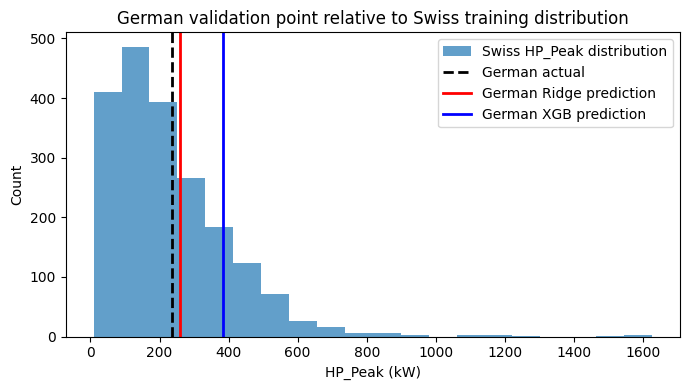

In [90]:
if len(german_idx) > 0:
    plt.figure(figsize=(7, 4))

    plt.hist(
        y_swiss_model,
        bins=20,
        alpha=0.7,
        label="Swiss HP_Peak distribution"
    )

    plt.axvline(
        actual,
        color="black",
        linestyle="--",
        linewidth=2,
        label="German actual"
    )

    plt.axvline(
        ridge_predicted,
        color="red",
        linestyle="-",
        linewidth=2,
        label="German Ridge prediction"
    )

    plt.axvline(
        xgb_predicted,
        color="blue",
        linestyle="-",
        linewidth=2,
        label="German XGB prediction"
    )

    plt.xlabel("HP_Peak (kW)")
    plt.ylabel("Count")
    plt.title("German validation point relative to Swiss training distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

# FeederBW

In [91]:
from pathlib import Path

feederbw_dir = Path('data/FeederBW')
measurement_dir = feederbw_dir / 'feeder_measurement_data_001-040' / 'feeder_measurement_data_001-040'

feeder_metadata_df = pd.read_csv(feederbw_dir / 'feeder_metadata.csv')
weather_data_df = pd.read_parquet(feederbw_dir / 'weather_data.parquet')

feeder_measurement_dfs = {}
for file_path in sorted(measurement_dir.rglob('feeder_*.parquet')):
    feeder_id = int(file_path.stem.split('_')[-1])
    feeder_measurement_dfs[feeder_id] = pd.read_parquet(file_path)

feeder_measurement_ids = sorted(feeder_measurement_dfs.keys())

feeder_metadata_df['date'] = pd.to_datetime(feeder_metadata_df['date'])
feeder_metadata_2024_df = feeder_metadata_df[
    (feeder_metadata_df['date'] >= '2024-01-01') &
    (feeder_metadata_df['date'] < '2025-01-01')
].copy()
feeder_metadata_2024_subset = feeder_metadata_2024_df[feeder_metadata_2024_df['feeder'].isin(feeder_measurement_ids)].copy()

feeder_metadata_start_2024_df = (
    feeder_metadata_2024_subset.sort_values('date')
    .drop_duplicates('feeder', keep='first')
    .set_index('feeder')
)
feeder_metadata_end_2024_df = (
    feeder_metadata_2024_subset.sort_values('date')
    .drop_duplicates('feeder', keep='last')
    .set_index('feeder')
)
feeder_metadata_static_all_df = (
    feeder_metadata_df.sort_values('date')
    .drop_duplicates('feeder', keep='first')
    .set_index('feeder')
)
feeder_metadata_static_last_all_df = (
    feeder_metadata_df.sort_values('date')
    .drop_duplicates('feeder', keep='last')
    .set_index('feeder')
)
feeder_metadata_static_df = feeder_metadata_start_2024_df.combine_first(feeder_metadata_static_all_df)

metadata_2024_changes = []
metadata_cols = [c for c in feeder_metadata_2024_subset.columns if c not in {'feeder', 'date'}]
for feeder_id, feeder_meta_group in feeder_metadata_2024_subset.groupby('feeder'):
    changed_cols = [
        col for col in metadata_cols
        if feeder_meta_group[col].nunique(dropna=False) > 1
    ]
    if changed_cols:
        metadata_2024_changes.append({
            'feeder': feeder_id,
            'n_records_2024': len(feeder_meta_group),
            'changed_columns': changed_cols,
            'heat_pumps_kW_start': feeder_metadata_start_2024_df.loc[feeder_id, 'heat_pumps_kW'] if feeder_id in feeder_metadata_start_2024_df.index else np.nan,
            'heat_pumps_kW_end': feeder_metadata_end_2024_df.loc[feeder_id, 'heat_pumps_kW'] if feeder_id in feeder_metadata_end_2024_df.index else np.nan,
        })

feeder_metadata_changes_2024_df = pd.DataFrame(metadata_2024_changes)

feeder_rows = {}
for feeder_id, feeder_df in feeder_measurement_dfs.items():
    feeder_df = feeder_df.copy()
    feeder_df['timestamp_UTC'] = pd.to_datetime(feeder_df['timestamp_UTC'], utc=True)
    feeder_df = feeder_df[(feeder_df['timestamp_UTC'] >= pd.Timestamp('2024-01-01', tz='UTC')) &
                          (feeder_df['timestamp_UTC'] < pd.Timestamp('2025-01-01', tz='UTC'))]
    feeder_df = feeder_df.sort_values('timestamp_UTC').set_index('timestamp_UTC')

    weather_df = weather_data_df[weather_data_df['feeder'] == feeder_id].copy()
    weather_df['timestamp_UTC'] = pd.to_datetime(weather_df['timestamp_UTC'], utc=True)
    weather_df = weather_df[(weather_df['timestamp_UTC'] >= pd.Timestamp('2024-01-01', tz='UTC')) &
                            (weather_df['timestamp_UTC'] < pd.Timestamp('2025-01-01', tz='UTC'))]
    weather_df = weather_df.sort_values('timestamp_UTC').set_index('timestamp_UTC')

    load_15min = feeder_df['active_power_kW'].resample('15min').mean().rename('Total_Load')
    temperature_15min = (
        weather_df['air_temperature_C']
        .resample('15min')
        .interpolate(method='time')
        .ffill()
        .bfill()
        .rename('Temperature')
    )

    aligned = pd.concat([load_15min, temperature_15min], axis=1, join='inner').dropna()
    if aligned.empty:
        continue

    if feeder_id in feeder_metadata_start_2024_df.index:
        start_row = feeder_metadata_start_2024_df.loc[feeder_id]
    elif feeder_id in feeder_metadata_static_all_df.index:
        start_row = feeder_metadata_static_all_df.loc[feeder_id]
    else:
        start_row = pd.Series(dtype=float)

    if feeder_id in feeder_metadata_end_2024_df.index:
        end_row = feeder_metadata_end_2024_df.loc[feeder_id]
    elif feeder_id in feeder_metadata_static_last_all_df.index:
        end_row = feeder_metadata_static_last_all_df.loc[feeder_id]
    else:
        end_row = pd.Series(dtype=float)

    row = {
        'feeder': feeder_id,
        'substation': start_row.get('substation', np.nan),
        'housing_units_count': start_row.get('housing_units_count', np.nan),
        'industry_and_commerce_count': start_row.get('industry_and_commerce_count', np.nan),
        'heat_pumps_kW_start': start_row.get('heat_pumps_kW', np.nan),
        'heat_pumps_kW_end': end_row.get('heat_pumps_kW', np.nan),
        'heat_pumps_kW_change': (
            end_row.get('heat_pumps_kW', np.nan) - start_row.get('heat_pumps_kW', np.nan)
            if pd.notna(start_row.get('heat_pumps_kW', np.nan)) and pd.notna(end_row.get('heat_pumps_kW', np.nan))
            else np.nan
        ),
        'Total_Load': aligned['Total_Load'],
        'Temperature': aligned['Temperature'],
    }
    feeder_rows[feeder_id] = row

feederbw_df = pd.DataFrame.from_dict(feeder_rows, orient='index')
feederbw_df.index.name = 'Feeder_ID'

print(f"FeederBW rows kept for 2024: {len(feederbw_df)}")
print(f"Feeders with metadata changes in 2024: {len(feeder_metadata_changes_2024_df)}")
feeder_metadata_changes_2024_df
feederbw_df

FeederBW rows kept for 2024: 40
Feeders with metadata changes in 2024: 26


,feeder,substation,housing_units_count,industry_and_commerce_count,heat_pumps_kW_start,heat_pumps_kW_end,heat_pumps_kW_change,Total_Load,Temperature
Feeder_ID,,,,,,,,,
1,1,1,70,11,2.10,2.10,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 43....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.5...
2,2,2,22,1,36.43,36.43,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 29....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.3...
3,3,3,68,0,0.00,12.00,12.0,timestamp_UTC 2024-01-01 00:00:00+00:00 10....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
4,4,4,28,4,13.00,13.00,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 16....,timestamp_UTC 2024-01-01 00:00:00+00:00 6.3...
5,5,5,62,0,0.00,0.00,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
6,6,6,40,1,14.72,14.72,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 20....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.8...
7,7,7,27,3,2.89,2.89,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 3.4...
8,8,8,61,0,34.36,34.36,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 30....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.0...
9,9,9,72,2,25.89,29.29,3.4,timestamp_UTC 2024-01-01 00:00:00+00:00 26....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.6...


In [92]:
feederbw_df.describe()

,feeder,substation,housing_units_count,industry_and_commerce_count,heat_pumps_kW_start,heat_pumps_kW_end,heat_pumps_kW_change
count,40.000000,40.000000,40.0000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,18.900000,37.2500,2.975000,7.904500,9.189500,1.285000
std,11.690452,10.601887,24.4695,3.415556,11.620348,12.278841,3.465326
min,1.000000,1.000000,0.0000,0.000000,0.000000,0.000000,0.000000
25%,10.750000,10.750000,20.2500,0.000000,0.000000,0.000000,0.000000
50%,20.500000,18.500000,33.0000,1.500000,2.845000,4.450000,0.000000
75%,30.250000,28.000000,54.2500,5.000000,10.482500,12.492500,0.000000
max,40.000000,37.000000,102.0000,12.000000,44.500000,44.500000,15.900000


In [93]:
feederbw_no_change_df = feederbw_df[feederbw_df['heat_pumps_kW_change'] == 0][['heat_pumps_kW_start', 'Total_Load','Temperature']].rename(columns={'heat_pumps_kW_start': 'HP_Peak'})
feederbw_no_change_df

,HP_Peak,Total_Load,Temperature
Feeder_ID,,,
1,2.10,timestamp_UTC 2024-01-01 00:00:00+00:00 43....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.5...
2,36.43,timestamp_UTC 2024-01-01 00:00:00+00:00 29....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.3...
4,13.00,timestamp_UTC 2024-01-01 00:00:00+00:00 16....,timestamp_UTC 2024-01-01 00:00:00+00:00 6.3...
5,0.00,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
6,14.72,timestamp_UTC 2024-01-01 00:00:00+00:00 20....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.8...
7,2.89,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 3.4...
8,34.36,timestamp_UTC 2024-01-01 00:00:00+00:00 30....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.0...
13,9.72,timestamp_UTC 2024-01-01 00:00:00+00:00 22....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.4...
15,18.00,timestamp_UTC 2024-01-01 00:00:00+00:00 10....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...


In [94]:
feederbw_windowed_hdd_df = extract_windowed_hdd_features_from_entity_dataframe(
    entity_df=feederbw_no_change_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=15.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs(),
)

Extracting windowed HDD-binned features: 100%|██████████| 33/33 [00:04<00:00,  7.70it/s]


In [95]:
xgb_pred_windowed_hdd_fbw = make_prediction_series(xgb_windowed_hdd_model, feederbw_windowed_hdd_df)
ridge_pred_windowed_hdd_fbw = make_prediction_series(ridge_windowed_hdd_model, feederbw_windowed_hdd_df)

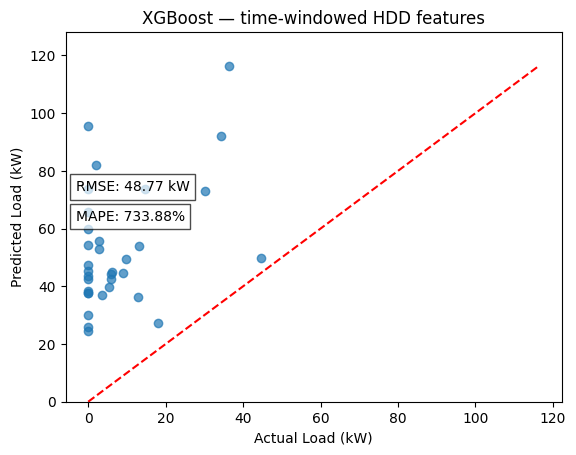

In [96]:
fig, ax, rmse, mape = plot_prediction_scatter(
    feederbw_no_change_df['HP_Peak'], xgb_pred_windowed_hdd_fbw, title='XGBoost — time-windowed HDD features')

plt.show()

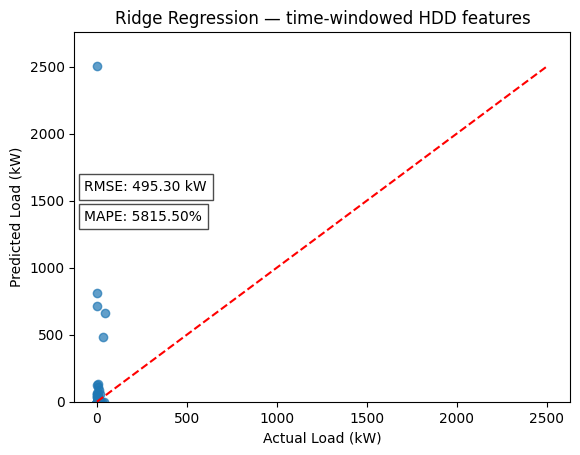

In [97]:
fig, ax, rmse, mape = plot_prediction_scatter(
    feederbw_no_change_df['HP_Peak'], ridge_pred_windowed_hdd_fbw, title='Ridge Regression — time-windowed HDD features')

plt.show()